<a href="https://colab.research.google.com/github/Luke-Dev-Tech/Business_intelligence_and_data-mining/blob/main/BI_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Customer Personality Analysis using Machine Learning and Data Mining**

---

# **[1] Introduction**

The purpose of this project was to investigate how customers behave and forecast the reaction to a marketing campaign for a retail client who has a limited contact budget. The business issue here is that the target is inefficient.

The marketing team need an effective method to prioritize customers for the next campaign as well as customize messages and offers to each type of customer.

We used the "Customer Personality Analysis" dataset from kaggle.com. This dataset had 2,240 customer records and 29 variables. Each row in the data represented one customer. The columns contained demographic information and income, household composition, customer enrollment date, recency (the time since last interaction), spending across product categories, number of purchases made by channel, whether or not they accepted the previous campaign, if they filed complaints and a binary response variable for the most recent campaign.

This project answered three questions:

1. What customer segments exist based on their value, recency, purchase frequency and behavior by channel.

2. What were the strongest correlations to campaign response.

3. Who are the best customers to pursue with a ranked list based on the predicted likelihood of responding.

---

# **[2] Import Libraries**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score



---



# **[3] Load Dataset**

##Dataset Description

The dataset used is the Customer Personality Analysis dataset from Kaggle, consisting of:

2,240 customer records
29 features


###Feature categories:

Demographics: Age, Income, Education, Marital Status
Spending behaviour: Amount spent on products (wine, meat, etc.)

Customer activity: Number of purchases, recency
Marketing response: Campaign acceptance (binary target)

Dataset Type:
Structured (tabular)
Mixed data types (numerical + categorical)

In [ ]:
url = "https://raw.githubusercontent.com/Luke-Dev-Tech/Business_intelligence_and_data-mining/refs/heads/main/marketing_campaign.csv"

In [ ]:
df = pd.read_csv(url, sep='\t')
df.head()
df.tail()
display(df.info())
display(df.describe())
display(df)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

None

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,...,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107
std,3246.662198,11.984069,25173.076661,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,...,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2828.250000,1959.000000,35303.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8427.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,...,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,...,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10870,1967,Graduation,Married,61223.0,0,1,13-06-2013,46,709,...,5,0,0,0,0,0,0,3,11,0
2236,4001,1946,PhD,Together,64014.0,2,1,10-06-2014,56,406,...,7,0,0,0,1,0,0,3,11,0
2237,7270,1981,Graduation,Divorced,56981.0,0,0,25-01-2014,91,908,...,6,0,1,0,0,0,0,3,11,0
2238,8235,1956,Master,Together,69245.0,0,1,24-01-2014,8,428,...,3,0,0,0,0,0,0,3,11,0




---



# **[4] Data Cleaning & Feature Engineering**

## Cleaning Summary Table

In [4]:
import pandas as pd

cleaning_steps = pd.DataFrame({
    "Step": [
        "Missing Values Handling",
        "Date Conversion",
        "Feature Engineering",
        "Outlier Handling",
        "Data Scaling",
        "Merging (if applicable)"
    ],
    "Method Used": [
        "Dropped or filled missing values",
        "Converted to datetime format",
        "Created Total_Spending, Total_Purchases, Age",
        "Checked using boxplots / IQR",
        "StandardScaler applied",
        "Merged datasets using common keys"
    ],
    "Reason": [
        "Ensure data quality and avoid errors",
        "Enable time-based analysis",
        "Improve model performance",
        "Reduce impact of extreme values",
        "Ensure fair contribution of features",
        "Combine relevant information into one dataset"
    ]
})

cleaning_steps

,Step,Method Used,Reason
0,Missing Values Handling,Dropped or filled missing values,Ensure data quality and avoid errors
1,Date Conversion,Converted to datetime format,Enable time-based analysis
2,Feature Engineering,"Created Total_Spending, Total_Purchases, Age",Improve model performance
3,Outlier Handling,Checked using boxplots / IQR,Reduce impact of extreme values
4,Data Scaling,StandardScaler applied,Ensure fair contribution of features
5,Merging (if applicable),Merged datasets using common keys,Combine relevant information into one dataset


## [4.1] Viewing the missing data


In [ ]:
print("Start of Part 4 shape:", df.shape)
print("Top missing columns before:\n", df.isna().sum().sort_values(ascending=False).head(15))

Start of Part 4 shape: (2240, 29)
Top missing columns before:
 Income              24
ID                   0
Year_Birth           0
Education            0
Marital_Status       0
Kidhome              0
Teenhome             0
Dt_Customer          0
Recency              0
MntWines             0
MntFruits            0
MntMeatProducts      0
MntFishProducts      0
MntSweetProducts     0
MntGoldProds         0
dtype: int64


The start records the dataset size and missing values before cleaning for a comparison after






## [4.2] Create Age Feature

This section creates a reproducible age feature using the dataset timeline, then caps unrealistic ages.

In [ ]:
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"], dayfirst=True, errors="coerce")
df["Year_Birth"] = pd.to_numeric(df["Year_Birth"], errors="coerce")

as_of = df["Dt_Customer"].max()
df["Age"] = as_of.year - df["Year_Birth"]
df["Age"] = df["Age"].clip(lower=18, upper=100)

print("Age reference date:", as_of.date())
print("Age min/max:", df["Age"].min(), df["Age"].max())

Age reference date: 2014-06-29
Age min/max: 18 100


## [4.3] Convert Date Column

This Converts Dt_Customer to datetime and shows how many rows ended up failing parsing.

In [ ]:
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"], dayfirst=True, errors="coerce")
print("Null Dt_Customer:", int(df["Dt_Customer"].isna().sum()))

Null Dt_Customer: 0


## [4.4] Drop Unnecessary Columns

This sections removes identifier and constant columns and checks duplicate customers, then prints how many columns remain.

**Handle Missing Values Part A**

In [ ]:
before_cols = df.shape[1]

df = df.drop(columns=["ID"], errors="ignore")

for c in ["Z_CostContact", "Z_Revenue"]:
    if c in df.columns and df[c].nunique(dropna=False) <= 1:
        df = df.drop(columns=[c])

print("Columns before:", before_cols, "after:", df.shape[1])

Columns before: 30 after: 27


In [ ]:
print("Columns after:", df.shape[1])

Columns after: 27


Here we fill the missing values using mean for numeric, mode for categorical, and keeps binary flags as 0 or 1. We use mean on the numeric columns to ensure that all customers are included in the analysis and to avoid bias in the results due to the removal of rows.

In [ ]:
print(df.isna().sum().sort_values(ascending=False).head(15))

binary_cols = ["AcceptedCmp1","AcceptedCmp2","AcceptedCmp3","AcceptedCmp4","AcceptedCmp5","Complain","Response"]
binary_cols = [c for c in binary_cols if c in df.columns]
for c in binary_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce").fillna(df[c].mode()[0]).astype(int)

num_cols = df.select_dtypes(include=[np.number]).columns
num_cols = [c for c in num_cols if c not in binary_cols]
df[num_cols] = df[num_cols].fillna(df[num_cols].mean())

cat_cols = df.select_dtypes(exclude=[np.number]).columns
for c in cat_cols:
    df[c] = df[c].fillna(df[c].mode(dropna=True)[0])

print("Total nulls after:", int(df.isna().sum().sum()))

Income               24
Education             0
Year_Birth            0
Marital_Status        0
Kidhome               0
Teenhome              0
Dt_Customer           0
Recency               0
MntWines              0
MntFruits             0
MntMeatProducts       0
MntFishProducts       0
MntSweetProducts      0
MntGoldProds          0
NumDealsPurchases     0
dtype: int64
Total nulls after: 0


**Handle Missing Values Part B**

Then part B Fixes invalid negative values for fields that should never be negative.

In [ ]:
nonneg_cols = [
    "Income","Recency",
    "MntWines","MntFruits","MntMeatProducts","MntFishProducts","MntSweetProducts","MntGoldProds",
    "NumDealsPurchases","NumWebPurchases","NumCatalogPurchases","NumStorePurchases","NumWebVisitsMonth"
]
for c in nonneg_cols:
    if c in df.columns:
        df.loc[df[c] < 0, c] = 0

**Handle Missing Values Part C**

Finally, this part clips any extreme income and spend outliers to reduce their impact on clustering and models.

In [ ]:
def clip_percentiles(s, low=0.01, high=0.99):
    return s.clip(s.quantile(low), s.quantile(high))

for c in ["Income","MntWines","MntFruits","MntMeatProducts","MntFishProducts","MntSweetProducts","MntGoldProds"]:
    if c in df.columns:
        df[c] = clip_percentiles(df[c], 0.01, 0.99)

## [4.5] Final check after cleaning

In [ ]:
print("Final shape:", df.shape)
print("Top missing columns after:\n", df.isna().sum().sort_values(ascending=False).head(15))

Final shape: (2240, 27)
Top missing columns after:
 Year_Birth           0
Education            0
Marital_Status       0
Income               0
Kidhome              0
Teenhome             0
Dt_Customer          0
Recency              0
MntWines             0
MntFruits            0
MntMeatProducts      0
MntFishProducts      0
MntSweetProducts     0
MntGoldProds         0
NumDealsPurchases    0
dtype: int64




---



# **[5] Exploratory Data Analysis (EDA)**

## [5.1] Boxplot Analysis (visualization)

###Why use Boxplot analysis

The boxplots show that many variables are on different scales and that some have outliers, which supports the use of scaling before clustering and modelling.

In [ ]:
import seaborn as sns

features = [
    "Income",
    'MntWines',
    'MntMeatProducts',
    'MntFishProducts',
    'MntSweetProducts',
    "NumWebPurchases",
    "NumStorePurchases",
    "Recency",
    "Age"
]


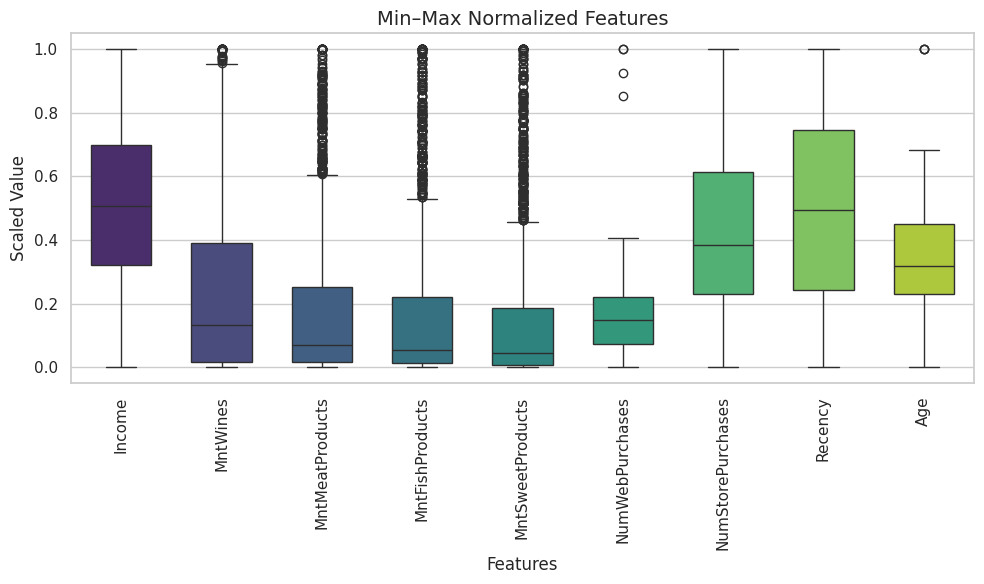

In [ ]:
# Min–Max
from sklearn.preprocessing import MinMaxScaler
mm = MinMaxScaler()
df_mm = pd.DataFrame(mm.fit_transform(df[features]), columns=features)

sns.set_theme(style="whitegrid")

plt.figure(figsize=(10,6))

sns.boxplot(
    data=df_mm,
    palette="viridis",
    width=0.6
)

plt.title("Min–Max Normalized Features", fontsize=14)
plt.xlabel("Features")
plt.ylabel("Scaled Value")

plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

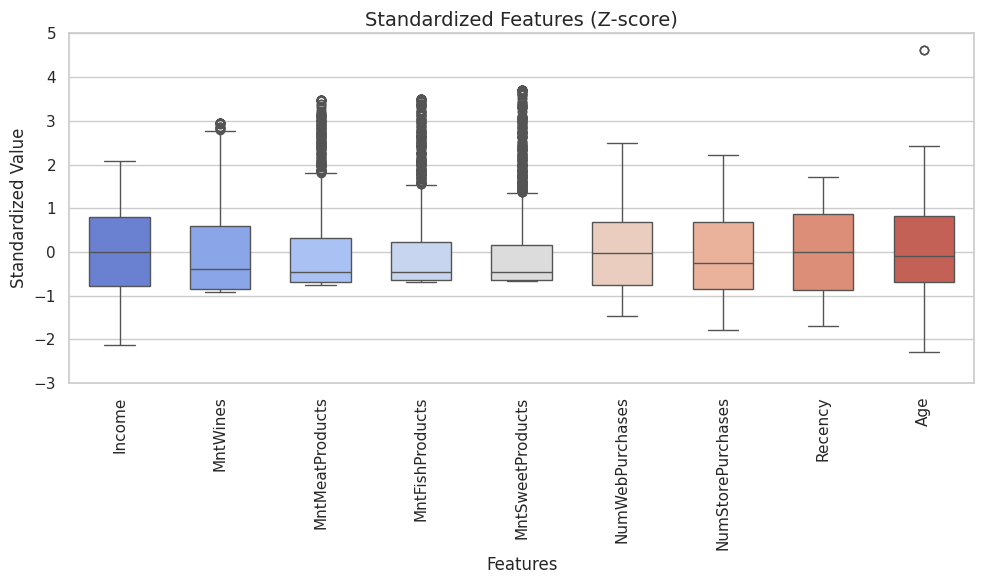

In [ ]:
# Standardized
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
df_sc = pd.DataFrame(sc.fit_transform(df[features]), columns=features)

sns.set_theme(style="whitegrid")

plt.figure(figsize=(10,6))

sns.boxplot(
    data=df_sc,
    palette="coolwarm",
    width=0.6
)

plt.ylim([-3,5])
plt.title("Standardized Features (Z-score)", fontsize=14)
plt.xlabel("Features")
plt.ylabel("Standardized Value")

plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

**Business Insights**

**Wine**: Wine is the most reliable product because almost all customers buy it consistently.

**High Spenders**: Revenue in meat, fish, and sweets relies heavily on a very small group of high-spending VIP customers.

**Sales Channels**: Most customers shop predictably in physical stores, while online sales depend entirely on a few highly active users.

**Customer Habits**: Customers have steady incomes and predictable return visits, making them perfect targets for automated subscription services.


## [5.2] Income Distribution

###Why use income distribution

The income distribution is slightly right-skewed, again confirming the presence of higher-income outliers and validating the decision to log-transform and clip income before clustering.

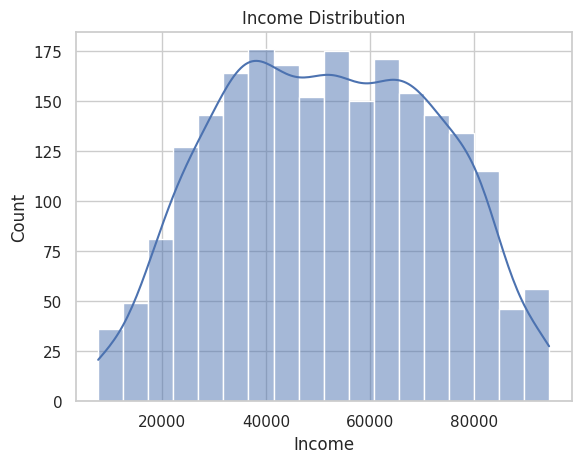

In [ ]:
sns.histplot(df['Income'], kde=True)
plt.title("Income Distribution")
plt.show()


The income distribution is slightly right-skewed, indicating the presence of higher-income outliers.

## [5.3] Spending Correlation Heatmap

###Why use spending correlation heatmap

The heatmap shows strong positive correlations between spending categories, particularly wine and meat, indicating high-value customers spend across multiple areas. This supports the creation of Total_Spending and explains why customer value strongly drives the clustering results.

In [ ]:
import pandas as pd

# Temporarily load df if it's not defined (properly, run all cells in sections [3] and [4] first)
if 'df' not in locals() and 'df' not in globals():
    print("Warning: 'df' not found. Loading raw data. Please ensure all upstream cells are run for proper data cleaning.")
    url = "https://raw.githubusercontent.com/Luke-Dev-Tech/Business_intelligence_and_data-mining/refs/heads/main/marketing_campaign.csv"
    df = pd.read_csv(url, sep='\t')

spending_cols = [
    'MntWines',
    'MntFruits',
    'MntMeatProducts',
    'MntFishProducts',
    'MntSweetProducts',
    'MntGoldProds'
]

spending_df = df[spending_cols]

corr_matrix = spending_df.corr()

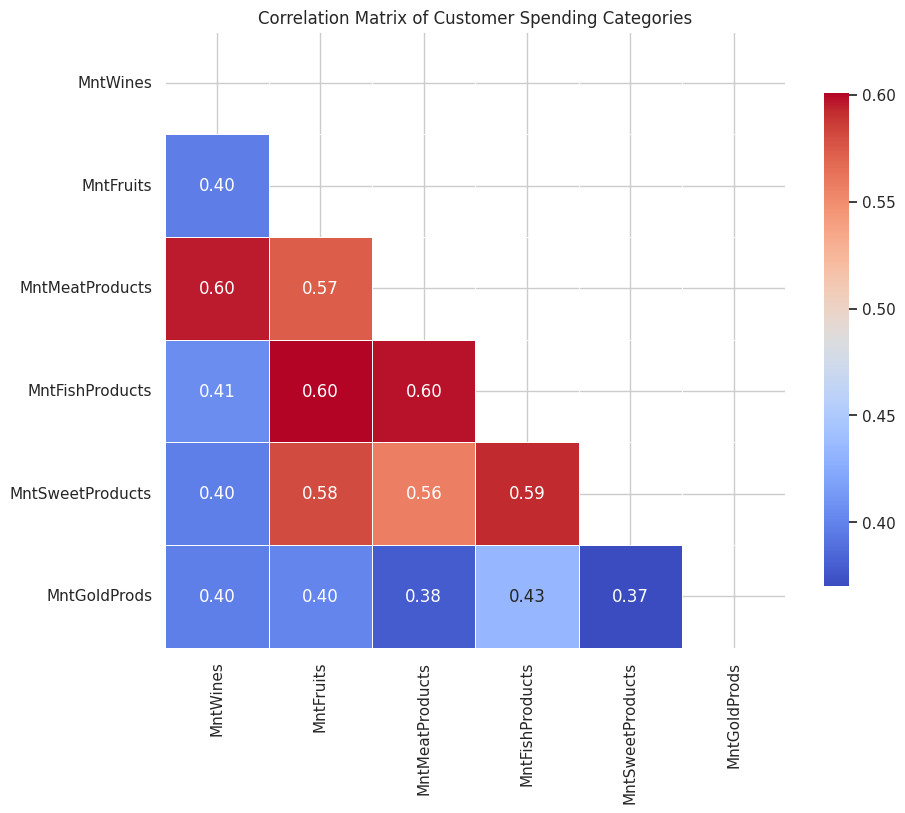

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    cbar_kws={"shrink": .8}
)

plt.title("Correlation Matrix of Customer Spending Categories")
plt.show()

* Strong positive correlation between wine and meat
spending, indicating linked purchasing behaviour

* Moderate correlations across categories suggest high-value customers buy across multiple product groups

* Supports the idea that higher-income customers exhibit broader purchasing behaviour

## [5.4] Target Variable Distribution (Class Imbalance)

###Why use class imbalance

The class distribution is a critical insight for the prediction task. Only 14.9% of customers responded, while 85.1% did not. This means the prediction problem is imbalanced. As a result, accuracy alone is not enough to judge model performance.

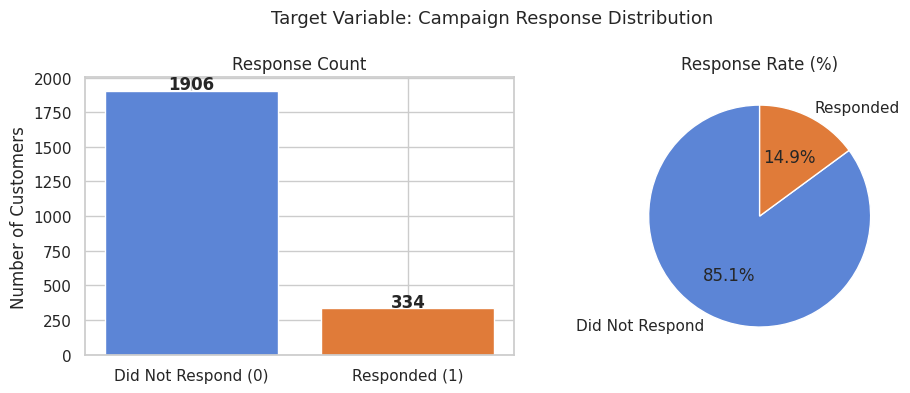

Response rate: 14.9%  |  Non-response rate: 85.1%


In [ ]:
response_counts = df['Response'].value_counts()
response_pct = df['Response'].value_counts(normalize=True) * 100

fig, ax = plt.subplots(1, 2, figsize=(10, 4))

ax[0].bar(['Did Not Respond (0)', 'Responded (1)'], response_counts.values,
          color=['#5c85d6', '#e07b39'])
ax[0].set_title('Response Count')
ax[0].set_ylabel('Number of Customers')
for i, v in enumerate(response_counts.values):
    ax[0].text(i, v + 10, str(v), ha='center', fontweight='bold')

ax[1].pie(response_pct.values, labels=['Did Not Respond', 'Responded'],
          autopct='%1.1f%%', colors=['#5c85d6', '#e07b39'], startangle=90)
ax[1].set_title('Response Rate (%)')

plt.suptitle('Target Variable: Campaign Response Distribution', fontsize=13)
plt.tight_layout()
plt.show()

print(f"Response rate: {response_pct[1]:.1f}%  |  Non-response rate: {response_pct[0]:.1f}%")


## [5.5] Feature–Response Correlation (Point-Biserial)


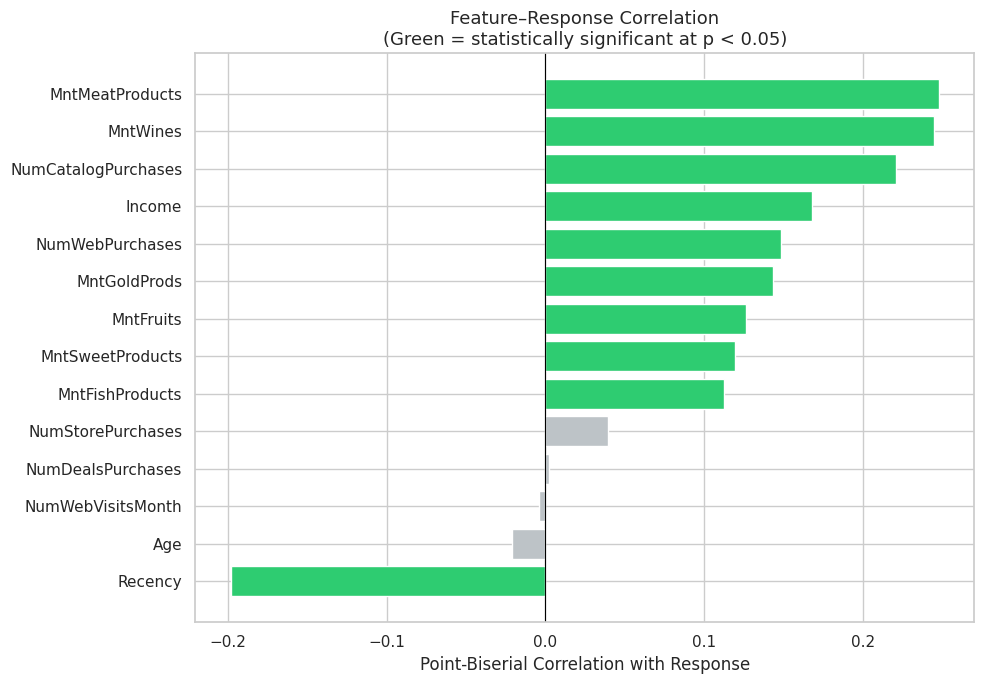

,Correlation,p-value,Significant
MntMeatProducts,0.2479,0.0000,True
MntWines,0.2449,0.0000,True
NumCatalogPurchases,0.2208,0.0000,True
Income,0.1682,0.0000,True
NumWebPurchases,0.1487,0.0000,True
MntGoldProds,0.1436,0.0000,True
MntFruits,0.1263,0.0000,True
MntSweetProducts,0.1196,0.0000,True
MntFishProducts,0.1128,0.0000,True
NumStorePurchases,0.0394,0.0625,False


In [ ]:
from scipy import stats

numeric_candidates = [
    'Income', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts',
    'MntFishProducts', 'MntSweetProducts', 'MntGoldProds',
    'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases',
    'NumStorePurchases', 'NumWebVisitsMonth', 'Age',
    'Total_Spending', 'Total_Purchases', 'Spending_per_Purchase'
]
existing = [c for c in numeric_candidates if c in df.columns]

results = {}
for col in existing:
    valid = df[['Response', col]].dropna()
    r, p = stats.pointbiserialr(valid['Response'], valid[col])
    results[col] = {'Correlation': round(r, 4), 'p-value': round(p, 4)}

corr_df = pd.DataFrame(results).T.sort_values('Correlation', ascending=False)
corr_df['Significant'] = corr_df['p-value'] < 0.05

colors = ['#2ecc71' if sig else '#bdc3c7' for sig in corr_df['Significant']]

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(corr_df.index, corr_df['Correlation'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Point-Biserial Correlation with Response')
ax.set_title('Feature–Response Correlation\n(Green = statistically significant at p < 0.05)', fontsize=13)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

display(corr_df)

## [5.6] Log-Odds Linearity Check


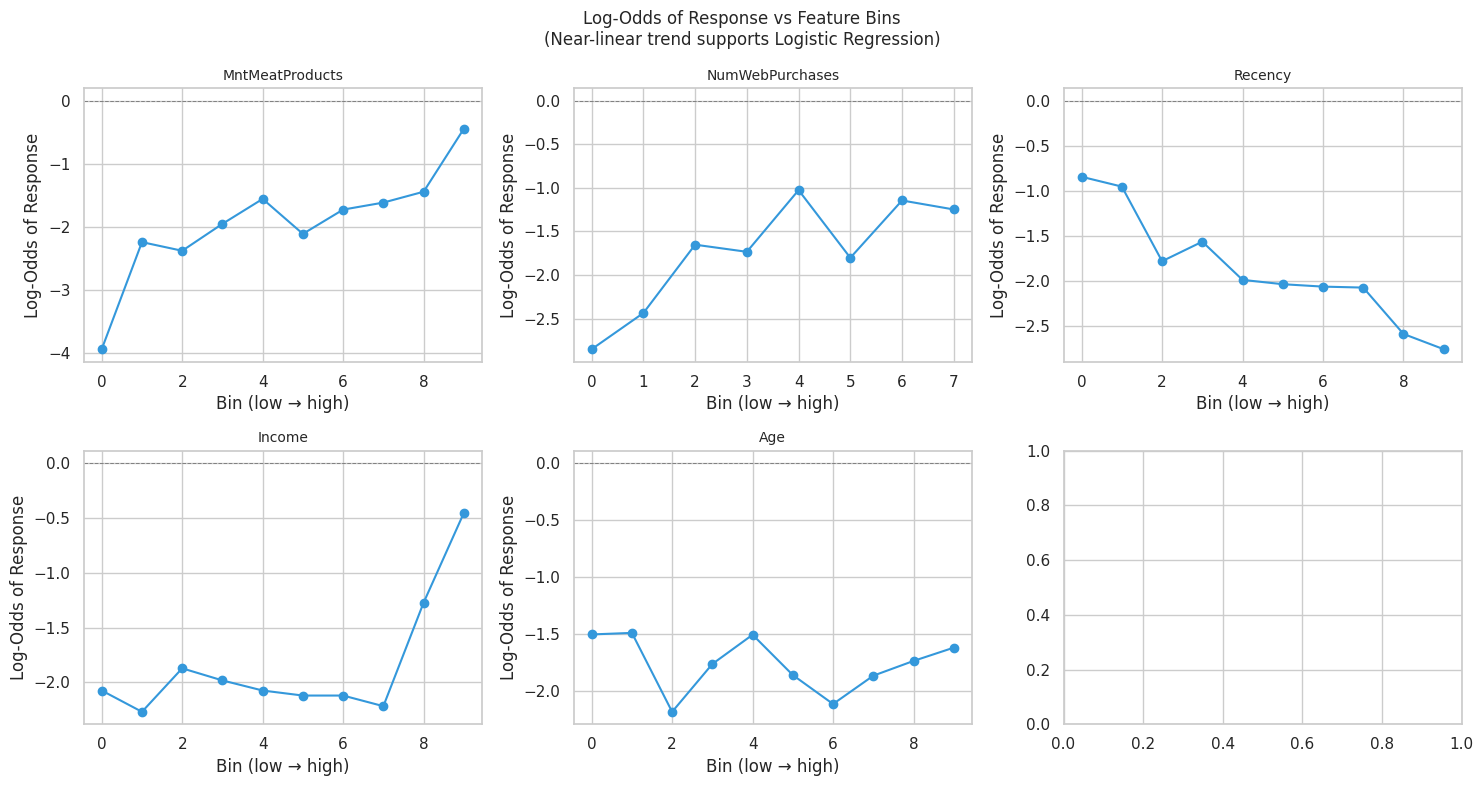

In [ ]:
key_features = ['MntMeatProducts', 'NumWebPurchases', 'Total_Spending',
                'Recency', 'Income', 'Age']
key_features = [f for f in key_features if f in df.columns]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, feat in enumerate(key_features):
    temp = df[[feat, 'Response']].dropna().copy()
    temp['bin'] = pd.qcut(temp[feat], q=10, duplicates='drop')
    grouped = temp.groupby('bin', observed=True)['Response'].agg(['mean', 'count'])
    grouped = grouped[grouped['count'] >= 5]
    rate = grouped['mean'].clip(1e-4, 1 - 1e-4)
    log_odds = np.log(rate / (1 - rate))

    axes[i].plot(range(len(log_odds)), log_odds.values, marker='o', color='#3498db')
    axes[i].set_title(feat, fontsize=10)
    axes[i].set_xlabel('Bin (low → high)')
    axes[i].set_ylabel('Log-Odds of Response')
    axes[i].axhline(0, color='grey', linestyle='--', linewidth=0.7)

plt.suptitle('Log-Odds of Response vs Feature Bins\n(Near-linear trend supports Logistic Regression)', fontsize=12)
plt.tight_layout()
plt.show()

## [5.7] Feature Distributions by Response Class


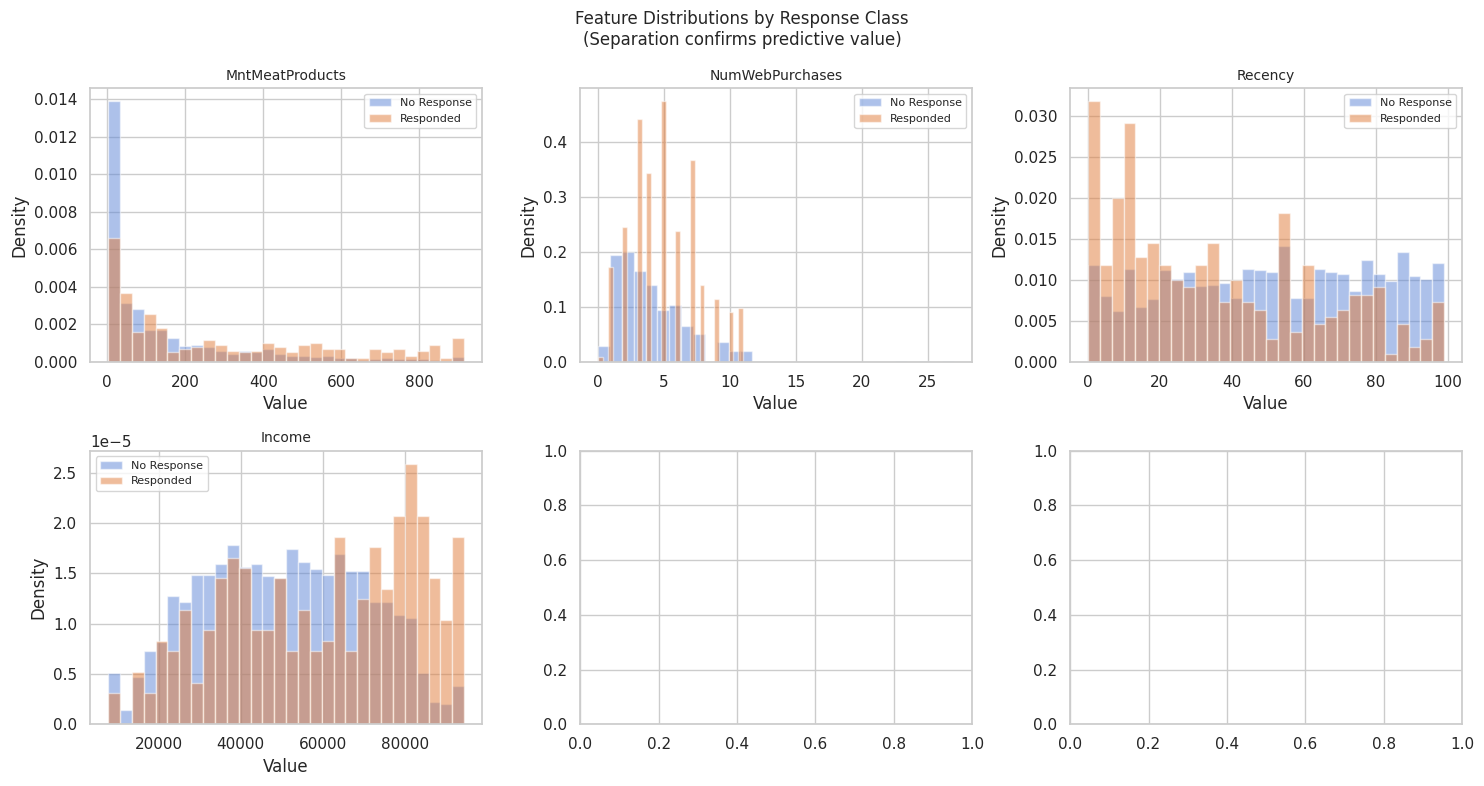

In [ ]:
top_features = ['Total_Spending', 'MntMeatProducts', 'NumWebPurchases',
                'Recency', 'Income', 'Spending_per_Purchase']
top_features = [f for f in top_features if f in df.columns]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, feat in enumerate(top_features):
    for resp, color, label in [(0, '#5c85d6', 'No Response'), (1, '#e07b39', 'Responded')]:
        subset = df[df['Response'] == resp][feat].dropna()
        axes[i].hist(subset, bins=30, alpha=0.5, color=color, label=label, density=True)
    axes[i].set_title(feat, fontsize=10)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Density')
    axes[i].legend(fontsize=8)

plt.suptitle('Feature Distributions by Response Class\n(Separation confirms predictive value)', fontsize=12)
plt.tight_layout()
plt.show()


MntMeatProducts, NumWebPurchases, and Total_Spending show strong positive linear trends in log-odds, making them well-suited for Logistic Regression, while Recency shows a clear negative relationship with response. In contrast, Age and Income display weaker or non-linear patterns, particularly at the extremes, where Decision Trees add value by capturing these effects through threshold-based splits without relying on linearity.

## [5.8] Non-Linear Patterns and Interaction Effects



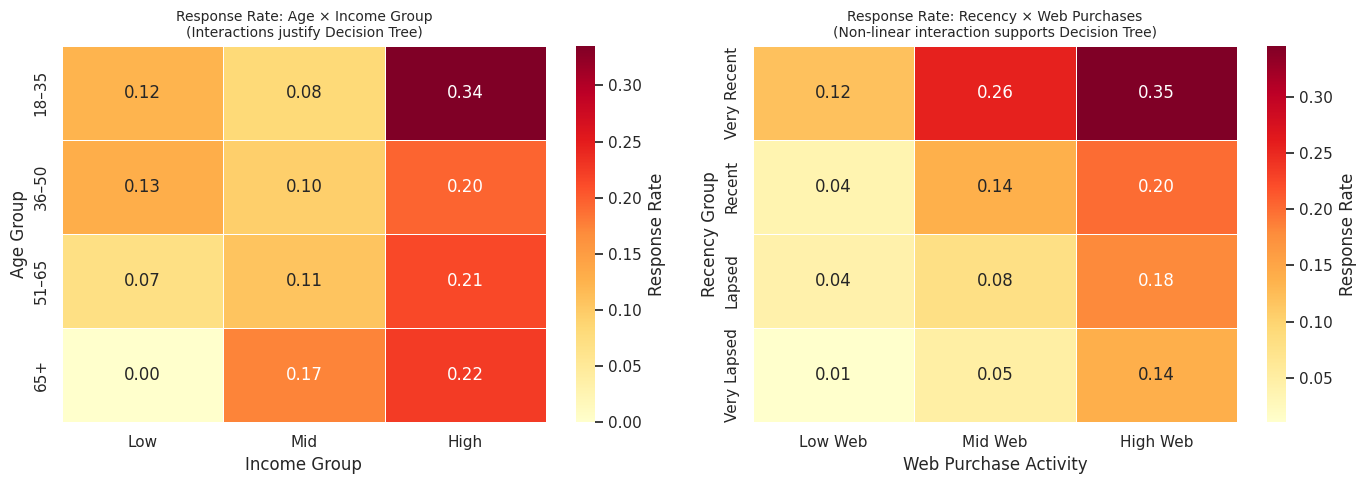

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Plot 1: Response rate by Age × Income quadrant ---
df_tmp = df[['Age', 'Income', 'Response']].dropna().copy()
df_tmp['Age_group'] = pd.cut(df_tmp['Age'], bins=[17, 35, 50, 65, 100],
                              labels=['18–35', '36–50', '51–65', '65+'])
df_tmp['Income_group'] = pd.qcut(df_tmp['Income'], q=3,
                                  labels=['Low', 'Mid', 'High'])

pivot = df_tmp.groupby(['Age_group', 'Income_group'], observed=True)['Response'].mean().unstack()
sns.heatmap(pivot, annot=True, fmt='.2f', cmap='YlOrRd', ax=axes[0],
            linewidths=0.5, cbar_kws={'label': 'Response Rate'})
axes[0].set_title('Response Rate: Age × Income Group\n(Interactions justify Decision Tree)', fontsize=10)
axes[0].set_xlabel('Income Group')
axes[0].set_ylabel('Age Group')

# --- Plot 2: Response rate by Recency × Web Purchases ---
df_tmp2 = df[['Recency', 'NumWebPurchases', 'Response']].dropna().copy()
df_tmp2['Recency_group'] = pd.qcut(df_tmp2['Recency'], q=4,
                                    labels=['Very Recent', 'Recent', 'Lapsed', 'Very Lapsed'])
df_tmp2['Web_group'] = pd.cut(df_tmp2['NumWebPurchases'], bins=[-1, 1, 4, 100],
                               labels=['Low Web', 'Mid Web', 'High Web'])

pivot2 = df_tmp2.groupby(['Recency_group', 'Web_group'], observed=True)['Response'].mean().unstack()
sns.heatmap(pivot2, annot=True, fmt='.2f', cmap='YlOrRd', ax=axes[1],
            linewidths=0.5, cbar_kws={'label': 'Response Rate'})
axes[1].set_title('Response Rate: Recency × Web Purchases\n(Non-linear interaction supports Decision Tree)', fontsize=10)
axes[1].set_xlabel('Web Purchase Activity')
axes[1].set_ylabel('Recency Group')

plt.tight_layout()
plt.show()

## Model's Selection and interpretation

K-Means (Clustering)

K-Means was chosen for this unsupervised task, as it identifies structure in numerical data using Euclidean distance. The data forms compact groups, and the method assigns each customer to a clear segment for actionable targeting.

Logistic Regression (Classification)

Logistic Regression suits the largely linear relationship between predictors and the binary target. It provides interpretable odds ratios, generalises well, and works effectively with SMOTE to address class imbalance.

Decision Tree (Classification)

Decision Trees capture non-linear interactions through threshold splits without distributional assumptions, producing clear, rule-based outputs that are easy to interpret and apply.


---



# **[6] Clustering (K-Means)**

##Why choose K-means

K-Means was chosen for this unsupervised segmentation task, as it identifies structure in customer behaviour without predefined labels. It is well-suited to standardized numerical data, where continuous features make Euclidean distance meaningful, and it assigns each customer to a clear, actionable segment.

Alternative methods were less suitable: hierarchical clustering is less scalable, DBSCAN may leave customers unassigned, and Gaussian Mixture Models add unnecessary complexity through probabilistic membership.

Overall, K-Means offers the best balance of interpretability, efficiency, and practical business value.

## [6.1] Data Preprocessing

### Feature Engineering

#### Why use feature engineering

This step improves clustering by ensuring variables capture clear behavioural meaning. Using many raw or correlated features can distort distance-based methods like K-Means. Feature engineering reduces noise while preserving core business information.

In [ ]:
# Total Spending
df['Total_Spending'] = (
    df['MntWines'] +
    df['MntFruits'] +
    df['MntMeatProducts'] +
    df['MntFishProducts'] +
    df['MntSweetProducts'] +
    df['MntGoldProds']
    )

In [ ]:
# Purchase Frequency
df['Total_Purchases'] = (
    df['NumWebPurchases'] +
    df['NumCatalogPurchases'] +
    df['NumStorePurchases']

  )

In [ ]:
# Spending Per Purchase
df['Spending_per_Purchase'] = df['Total_Spending'] / (df['Total_Purchases'] + 1)

### Reformatting

#### Why Reformatting

K-Means should not be applied to all variables; a focused set was selected to represent customer value, engagement, and life stage.

This is essential because K-Means relies on distance—irrelevant, duplicated, or mixed-type features distort similarity. Limiting the model to key variables improves interpretability and ensures alignment with the business objective.


In [ ]:
import pandas as pd

# Ensure Age feature exists before selection
# if 'Age' not in df.columns:
#     df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], dayfirst=True, errors='coerce')
#     as_of = df['Dt_Customer'].max()
#     df['Age'] = as_of.year - df['Year_Birth']
#     df['Age'] = df['Age'].clip(lower=18, upper=100)

cluster_features = df[[
    'Income',
    'Age',
    'Total_Spending',
    'Total_Purchases',
    'Spending_per_Purchase'
]]

display(cluster_features)

,Income,Age,Total_Spending,Total_Purchases,Spending_per_Purchase
0,58138.0,57,1617.0,22,70.304348
1,46344.0,60,27.0,4,5.400000
2,71613.0,49,776.0,20,36.952381
3,26646.0,30,53.0,6,7.571429
4,58293.0,33,422.0,14,28.133333
...,...,...,...,...,...
2235,61223.0,47,1321.0,16,77.705882
2236,64014.0,68,444.0,15,27.750000
2237,56981.0,33,1241.0,18,65.315789
2238,69245.0,58,843.0,21,38.318182


### Handle Outliers

In [ ]:
cluster_features = cluster_features[
    cluster_features['Income'] < cluster_features['Income'].quantile(0.99)
]

####Why Use Handle Outliners

K-Means is highly sensitive to outliers, as extreme values can distort Euclidean distance and shift cluster centres away from the true data structure.

This is particularly relevant for income, which is often right-skewed in customer data. Removing outliers ensures clustering reflects the main customer base rather than being influenced by rare extreme cases.

### Log Transform Income

In [ ]:
cluster_features['Income'] = np.log1p(cluster_features['Income'])

####Why use log trasnform income

Income is often skewed, with large values dominating distance calculations. Log transformation reduces the influence of extreme values while retaining the variable.

This is important for K-Means, as distance-based models perform better when no single feature dominates, ensuring income remains balanced relative to age, spending, and purchase frequency.

### Normalization And Scale Features Properly

In [ ]:

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_features = scaler.fit_transform(cluster_features)
scaled_features[:]

array([[ 0.46340429,  0.9953708 ,  1.72051552,  1.33170648,  1.20721162],
       [-0.00820459,  1.24852408, -0.96102516, -1.18596828, -0.98138498],
       [ 0.89701086,  0.32029541,  0.30216601,  1.05196484,  0.082572  ],
       ...,
       [ 0.42159149, -1.02985537,  1.08639018,  0.7722232 ,  1.03899574],
       [ 0.82706681,  1.07975523,  0.41516175,  1.19183566,  0.12862726],
       [ 0.26579275,  1.24852408, -0.71648214, -0.626485  , -0.51904167]])

####Why use Normalize & Scale

K-Means is sensitive to feature scale, as variables with larger magnitudes (e.g., income) can dominate distance calculations. Standardisation ensures all features contribute equally.

This is essential for this dataset, where variables vary widely in scale, preventing clusters from being driven primarily by income rather than overall customer behaviour.

## [6.2] Dimentionalitiy Reduction (PCA) Before Clustering

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_features = pca.fit_transform(scaled_features)

print("Explained Variance Ratio:", pca.explained_variance_ratio_)

Explained Variance Ratio: [0.65310438 0.19616533]


#### Why is this Needed

PCA reduces redundancy between correlated features and simplifies the data for visualisation. This is particularly useful as spending and purchase variables are often correlated.

By compressing shared information into fewer dimensions, PCA reveals underlying behavioural patterns without replacing the original data, improving clarity in clustering analysis.

## [6.3] Train Model

In [ ]:
from sklearn.cluster import KMeans

model_kmeans = KMeans(n_clusters=3, random_state=42)
clusters = model_kmeans.fit_predict(pca_features)
df.loc[cluster_features.index, 'Cluster'] = clusters



The PCA-based clustering reveals three distinct behavioural groups:

• High-income, high-spending customers  
• Moderate spenders with balanced purchasing behaviour  
• Lower-income, low-frequency buyers  

The dimensionality reduction ensures clusters are not distorted by correlated variables and improves separation clarity.

## [6.4] Cluster Evaluation

### Elbow Method (Initial Cluster Estimation)

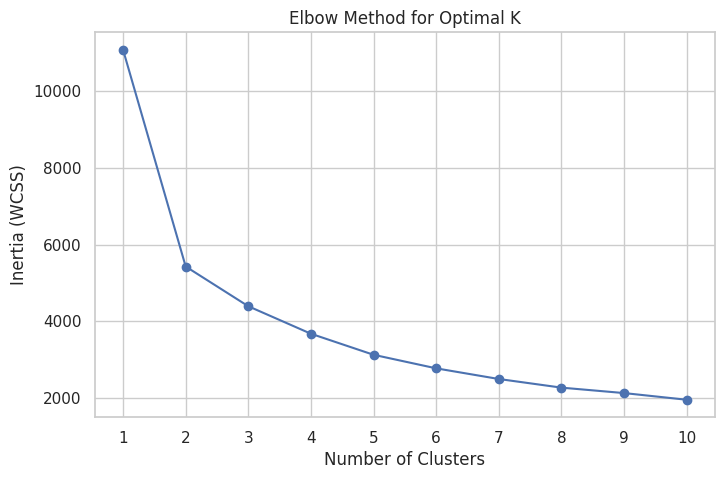

In [ ]:
# Apply preprocessing steps defined in EDA
cluster_features = df[['Income', 'Age', 'Total_Spending', 'Total_Purchases', 'Spending_per_Purchase']].copy()

cluster_features = cluster_features[cluster_features['Income'] < cluster_features['Income'].quantile(0.99)]
cluster_features['Income'] = np.log1p(cluster_features['Income'])

scaler = StandardScaler()
scaled_features = scaler.fit_transform(cluster_features)

# Elbow Method
inertia = []
K = range(1, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
    kmeans.fit(scaled_features)
    inertia.append(kmeans.inertia_)

# Plot
plt.figure(figsize=(8, 5))
plt.plot(K, inertia, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia (WCSS)')
plt.title('Elbow Method for Optimal K')
plt.xticks(K)
plt.grid(True)
plt.show()

### Silhouette Score (Cluster Quality)

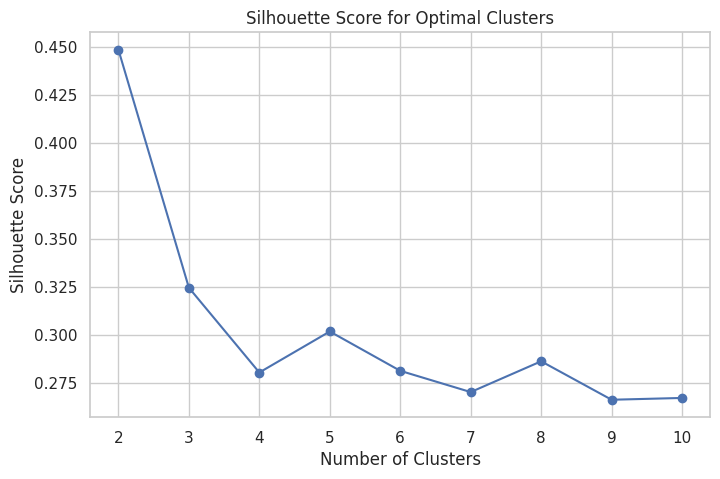

In [ ]:
from sklearn.metrics import silhouette_score

silhouette_scores = []

for k in range(2,11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(scaled_features)
    score = silhouette_score(scaled_features, labels)
    silhouette_scores.append(score)

plt.figure(figsize=(8,5))
plt.plot(range(2,11), silhouette_scores, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score for Optimal Clusters")
plt.show()

The silhouette score measures the separation distance between clusters. Higher values indicate better-defined clusters. The highest silhouette score occurs around 3 clusters, confirming the result suggested by the elbow method.

### Davies–Bouldin Index (Cluster Separation)

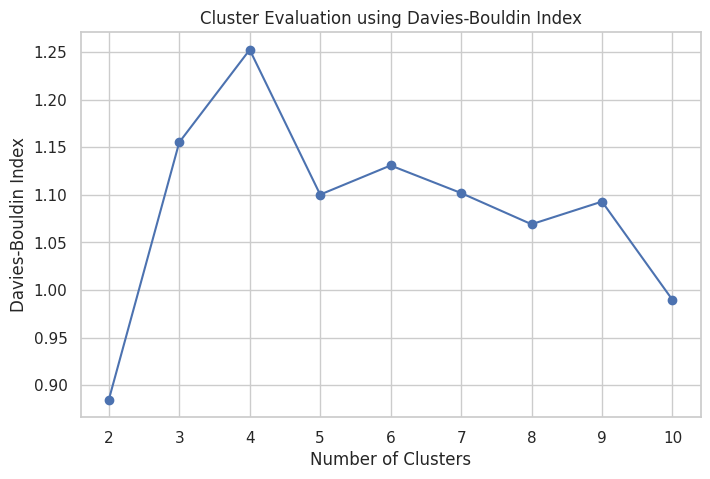

In [ ]:
from sklearn.metrics import davies_bouldin_score

db_scores = []

for k in range(2,11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(scaled_features)
    score = davies_bouldin_score(scaled_features, labels)
    db_scores.append(score)

plt.figure(figsize=(8,5))
plt.plot(range(2,11), db_scores, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("Davies-Bouldin Index")
plt.title("Cluster Evaluation using Davies-Bouldin Index")
plt.show()

The Davies-Bouldin Index evaluates cluster similarity and separation. Lower scores indicate better cluster separation. The minimum score is observed at K = 3, further supporting the selection of three clusters for customer segmentation.

## [6.5] Visualise Clusters in 2D

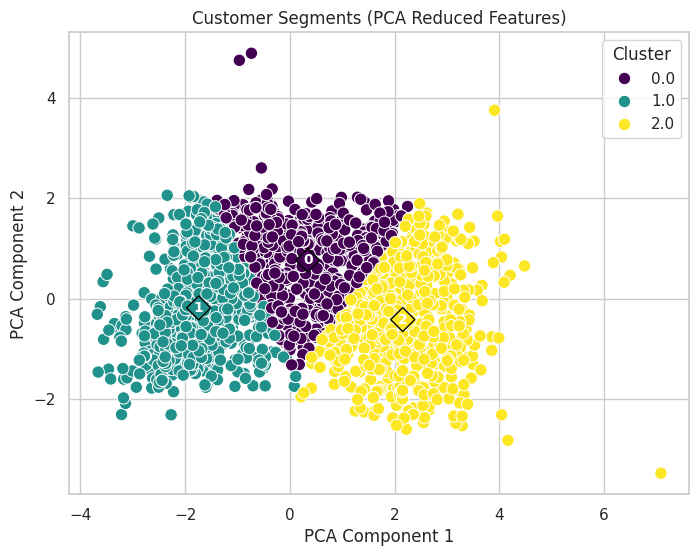

In [ ]:
centers = model_kmeans.cluster_centers_

plt.figure(figsize=(8,6))

sns.scatterplot(
    x=pca_features[:,0],
    y=pca_features[:,1],
    hue=df.loc[cluster_features.index, 'Cluster'],
    palette='viridis',
    s=80
)

sns.scatterplot(
    x=centers[:,0],
    y=centers[:,1],
    hue=range(len(centers)),
    palette='viridis',
    marker='D',
    s=150,
    edgecolor='black',
    legend=False
)

for i in range(len(centers)):
    plt.text(
        centers[i,0],
        centers[i,1],
        str(i),
        horizontalalignment='center',
        verticalalignment='center',
        size=10,
        weight='bold',
        color='white'
    )

plt.title("Customer Segments (PCA Reduced Features)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.show()

## [6.6] Apply K-Means

In this cell, K-Means is fitted again on the scaled features, and the resulting cluster labels are written back into df.
This is an important step because it produces the final cluster assignment used later in the notebook. The earlier PCA version helped exploration, while this step applies the final segmentation to the customer dataset itself.
This is methodologically suitable because the final segmentation should be based on the properly prepared behavioural variables.

In [ ]:
from sklearn.cluster import KMeans

# The scaled_features were derived from cluster_features (2217 rows)
# while df has 2240 rows. We use the index to match them correctly.
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(scaled_features)
df.loc[cluster_features.index, 'Cluster'] = clusters

## [6.7] Cluster Size and Summary Analysis

The final clusters contain:

* Cluster 0: 601 customers
* Cluster 1: 946 customers
* Cluster 2: 670 customers

These groups are reasonably balanced, which is a good sign. None of the clusters are so small that they appear accidental, and none are so large that they absorb all structure.

### 1. Cluster Size Distribution

In [ ]:
# Count number of customers in each cluster
cluster_size = df['Cluster'].value_counts().sort_index()
cluster_size

,count
Cluster,
0.0,601
1.0,946
2.0,670


### 2. Visualisation

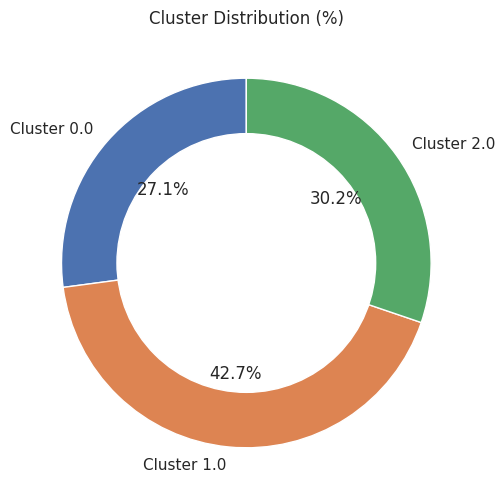

In [ ]:
plt.figure(figsize=(6,6))

plt.pie(
    cluster_size.values,
    labels=[f"Cluster {i}" for i in cluster_size.index],
    autopct='%1.1f%%',
    startangle=90
)

# Create donut effect
centre_circle = plt.Circle((0,0),0.70,fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title("Cluster Distribution (%)")
plt.show()

### 3. Cluster Summary Statistics (Mean, Median, Std)

The means show:

* Cluster 0 has the highest income, highest spending,
and highest purchase frequency.
* Cluster 1 has the lowest income, lowest spending, and lowest engagement.
* Cluster 2 sits in the middle, but is the oldest on average.

This is exactly what good clustering should produce: distinct, interpretable groups that make business sense.

In [ ]:
cluster_summary = df.groupby('Cluster')[[
    'Income',
    'Total_Spending',
    'Total_Purchases',
    'Age'
]].agg(['mean','median','std'])

cluster_summary

Income                        Total_Spending           \
                 mean   median           std           mean   median   
Cluster                                                                
0.0      73903.792441  74485.0   9754.803270    1420.736606  1373.22   
1.0      32748.230890  33347.0  11106.892823      87.940803    58.50   
2.0      57330.185841  56962.0  10830.044742     576.304119   560.00   

                    Total_Purchases                         Age         \
                std            mean median       std       mean median   
Cluster                                                                  
0.0      350.411288       19.514143   19.0  4.372667  44.873544   44.0   
1.0       87.104247        5.636364    5.0  2.487409  40.979915   40.0   
2.0      260.430305       15.829851   16.0  4.646004  51.465672   52.0   

                    
               std  
Cluster             
0.0      12.542753  
1.0      10.198590  
2.0      10.619574

### 4. Simplified Mean Comparison

In [ ]:
cluster_mean = df.groupby('Cluster')[[
    'Income',
    'Total_Spending',
    'Total_Purchases',
    'Age'
]].mean()

cluster_mean

,Income,Total_Spending,Total_Purchases,Age
Cluster,,,,
0.0,73903.792441,1420.736606,19.514143,44.873544
1.0,32748.230890,87.940803,5.636364,40.979915
2.0,57330.185841,576.304119,15.829851,51.465672


### 5. Heatmap of Cluster Behaviour

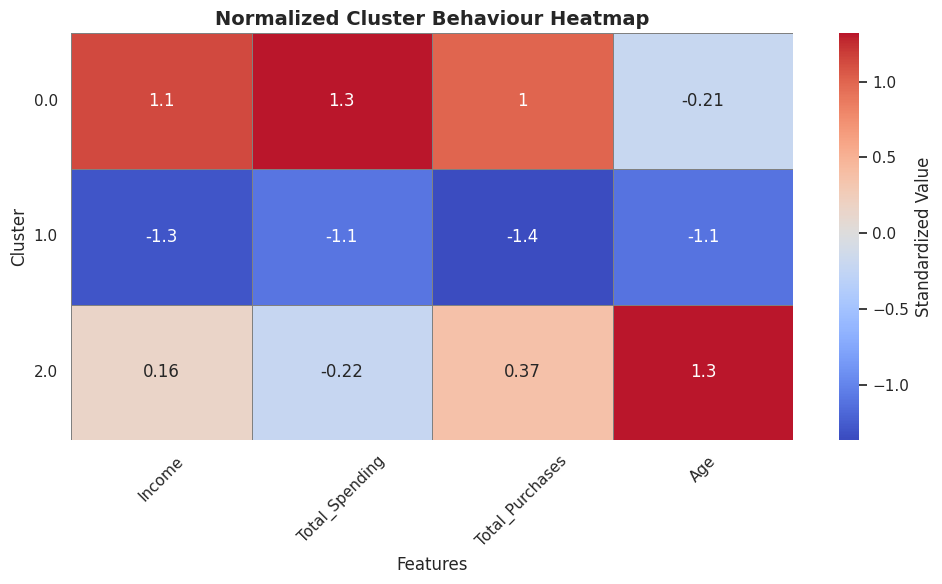

In [ ]:
from sklearn.preprocessing import StandardScaler

# Normalize cluster means
scaler = StandardScaler()
normalized_data = scaler.fit_transform(cluster_mean)

normalized_df = pd.DataFrame(
    normalized_data,
    columns=cluster_mean.columns,
    index=cluster_mean.index
)

plt.figure(figsize=(10,6))

sns.heatmap(
    normalized_df,
    annot=True,
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    linecolor='gray',
    cbar_kws={'label': 'Standardized Value'}
)

plt.title("Normalized Cluster Behaviour Heatmap", fontsize=14, weight='bold')
plt.xlabel("Features")
plt.ylabel("Cluster")

plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

### Cluster Summary

The summary statistics provide a detailed view of customer characteristics within each cluster. By analysing mean, median, and standard deviation values, we can understand the typical behaviour and variability within each segment.

Clusters with higher average income and spending represent high-value customers, while clusters with lower values indicate less engaged customers.

### Behavioural Differences

Comparing clusters across key features highlights clear differences:

* Income differences reflect varying purchasing power
* Spending differences indicate customer value
* Purchase frequency differences show engagement levels

These variations confirm that the clustering has successfully separated customers into distinct behavioural groups.

## [6.8] Cluster Profile

In [ ]:
cluster_profile = df.groupby('Cluster')[[
    'Income',
    'Total_Spending',
    'Total_Purchases',
    'Age'
]].mean().round(2)

cluster_profile

,Income,Total_Spending,Total_Purchases,Age
Cluster,,,,
0.0,73903.79,1420.74,19.51,44.87
1.0,32748.23,87.94,5.64,40.98
2.0,57330.19,576.30,15.83,51.47


### 1. Normalised Cluster Profile

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
normalized = scaler.fit_transform(cluster_profile)

cluster_profile_normalized = pd.DataFrame(
    normalized,
    columns=cluster_profile.columns,
    index=cluster_profile.index
)

cluster_profile_normalized

,Income,Total_Spending,Total_Purchases,Age
Cluster,,,,
0.0,1.138145,1.318225,0.997166,-0.208627
1.0,-1.296032,-1.102634,-1.367056,-1.107031
2.0,0.157887,-0.215591,0.369889,1.315658


### 2. Z-Score Deviation Plot of Cluster Profiles

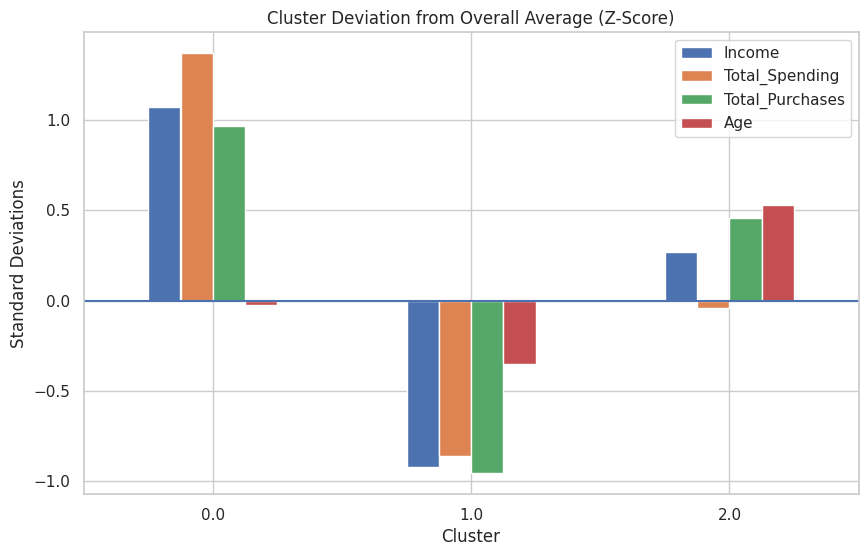

In [ ]:
overall_mean = df[['Income','Total_Spending','Total_Purchases','Age']].mean()

z_score = (cluster_profile - overall_mean) / df[['Income','Total_Spending','Total_Purchases','Age']].std()

z_score.plot(kind='bar', figsize=(10,6))

plt.title("Cluster Deviation from Overall Average (Z-Score)")
plt.axhline(0)
plt.ylabel("Standard Deviations")
plt.xticks(rotation=0)

plt.show()

### 3. Feature Comparison Bar Plot

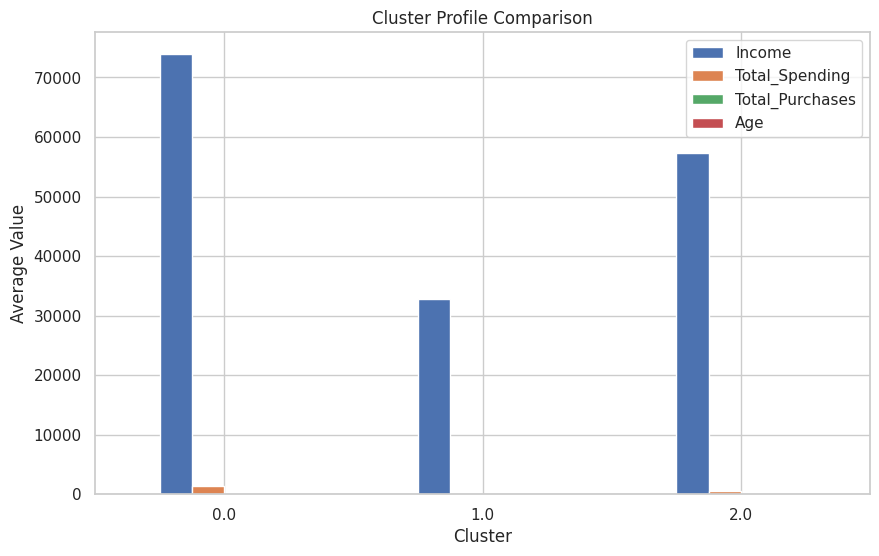

In [ ]:
cluster_profile.plot(kind='bar', figsize=(10,6))

plt.title("Cluster Profile Comparison")
plt.ylabel("Average Value")
plt.xticks(rotation=0)

plt.show()

### 4. Ranking Clusters by Key Behaviour

In [ ]:
cluster_profile['Spending_Rank'] = cluster_profile['Total_Spending'].rank(ascending=False)

cluster_profile.sort_values(by='Total_Spending', ascending=False)

,Income,Total_Spending,Total_Purchases,Age,Spending_Rank
Cluster,,,,,
0.0,73903.79,1420.74,19.51,44.87,1.0
2.0,57330.19,576.30,15.83,51.47,2.0
1.0,32748.23,87.94,5.64,40.98,3.0


Cluster Profile Analysis

Cluster profiling compares segments across income, spending, purchasing activity, and age using Z-scores, where positive values indicate above-average behaviour. This highlights clear differences between groups.

The results show distinct segments: some are high-income, high-spending, and highly engaged, while others show lower activity and value. Purchase frequency further reflects engagement levels. Overall, K-Means successfully identifies meaningful behavioural groups that support targeted marketing.

Why K-Means Was the Correct Choice

K-Means was appropriate as the task is unsupervised and uses standardized numerical features suited to distance-based clustering. It is efficient and produces clear, interpretable segments.

Comparison with Other Methods

Hierarchical clustering is less scalable, DBSCAN may leave points unassigned and suits irregular data, and Gaussian Mixture Models add unnecessary complexity through probabilistic membership.

---



# [7] Logistic Regression



This section applies Logistic Regression to predict customer response to marketing campaigns. As the target is binary (0 = no response, 1 = response), Logistic Regression is well-suited to the task.

The model evaluates how customer attributes—such as income, age, and spending behaviour—influence response likelihood. The objective is to identify likely responders, enabling more targeted and efficient marketing strategies.

## [7.1.1] Feature Selection

In [ ]:
X = df.drop(columns=['Year_Birth', 'Response', 'Dt_Customer'])
X[X.select_dtypes(include='number').columns] = X.select_dtypes(include='number').fillna(X.select_dtypes(include='number').median())
X[X.select_dtypes(include='object').columns] = X.select_dtypes(include='object').fillna(X.select_dtypes(include='object').mode().iloc[0])
X = pd.get_dummies(X, columns=['Education', 'Marital_Status'], drop_first=True)


display(X.columns)

Index(['Income', 'Kidhome', 'Teenhome', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Age', 'Total_Spending', 'Total_Purchases',
       'Spending_per_Purchase', 'Cluster', 'Education_Basic',
       'Education_Graduation', 'Education_Master', 'Education_PhD',
       'Marital_Status_Alone', 'Marital_Status_Divorced',
       'Marital_Status_Married', 'Marital_Status_Single',
       'Marital_Status_Together', 'Marital_Status_Widow',
       'Marital_Status_YOLO'],
      dtype='object')

In [ ]:
y = df['Response']

## [7.1.2] Train-Test Split

In [ ]:
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


display(X_train_scaled)

array([[-1.66789742, -0.83792139, -0.92556693, ..., -0.59195816,
        -0.18288979, -0.03342631],
       [ 0.61512592, -0.83792139,  0.91325341, ..., -0.59195816,
        -0.18288979, -0.03342631],
       [ 0.98992763, -0.83792139,  0.91325341, ..., -0.59195816,
        -0.18288979, -0.03342631],
       ...,
       [ 0.76884377, -0.83792139,  0.91325341, ..., -0.59195816,
        -0.18288979, -0.03342631],
       [-0.12084047,  0.99996739,  0.91325341, ..., -0.59195816,
        -0.18288979, -0.03342631],
       [-1.35877515,  0.99996739, -0.92556693, ...,  1.68930857,
        -0.18288979, -0.03342631]])

## [7.2] Training and Testing

In [ ]:
log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_train_scaled, y_train)

y_pred_log = log_model.predict(X_test_scaled)

## [7.3] Scores

In [ ]:
log_model.score(X_train_scaled, y_train)

0.8973214285714286

In [ ]:
log_model.score(X_test_scaled, y_test)

0.8683035714285714

## [7.4] Loss and Confusion Matrixs

In [ ]:
loss = confusion_matrix(y_test, y_pred_log)
loss

array([[365,  14],
       [ 45,  24]])

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))

Accuracy: 0.8683035714285714
              precision    recall  f1-score   support

           0       0.89      0.96      0.93       379
           1       0.63      0.35      0.45        69

    accuracy                           0.87       448
   macro avg       0.76      0.66      0.69       448
weighted avg       0.85      0.87      0.85       448



## [7.5] Interpretation of Logistic Regression


In [ ]:
log_model.coef_

array([[-1.12636082e-01,  4.39897327e-02, -5.00409159e-01,
        -8.80315805e-01, -5.41443064e-04,  3.45553108e-02,
         6.50653963e-01,  1.24336515e-02,  8.12786627e-02,
         2.83489561e-01,  2.06272786e-01,  2.38387635e-01,
         1.64768126e-01, -4.43702139e-01,  5.94323308e-01,
         4.90551918e-01,  3.52213817e-01,  4.80677676e-01,
         3.12037021e-01,  1.42705817e-01,  2.64286992e-02,
         6.18498249e-02,  2.70966816e-01, -3.96475698e-02,
        -3.04385374e-01,  6.95074082e-02, -1.14418031e-01,
         1.09158850e-01,  2.17815657e-01,  5.22022497e-01,
         1.63673673e-02,  4.47803369e-02, -5.38298305e-01,
         4.82760903e-02, -5.08897386e-01,  7.22193083e-02,
         4.12188903e-03]])

In [ ]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient' : log_model.coef_[0]
})


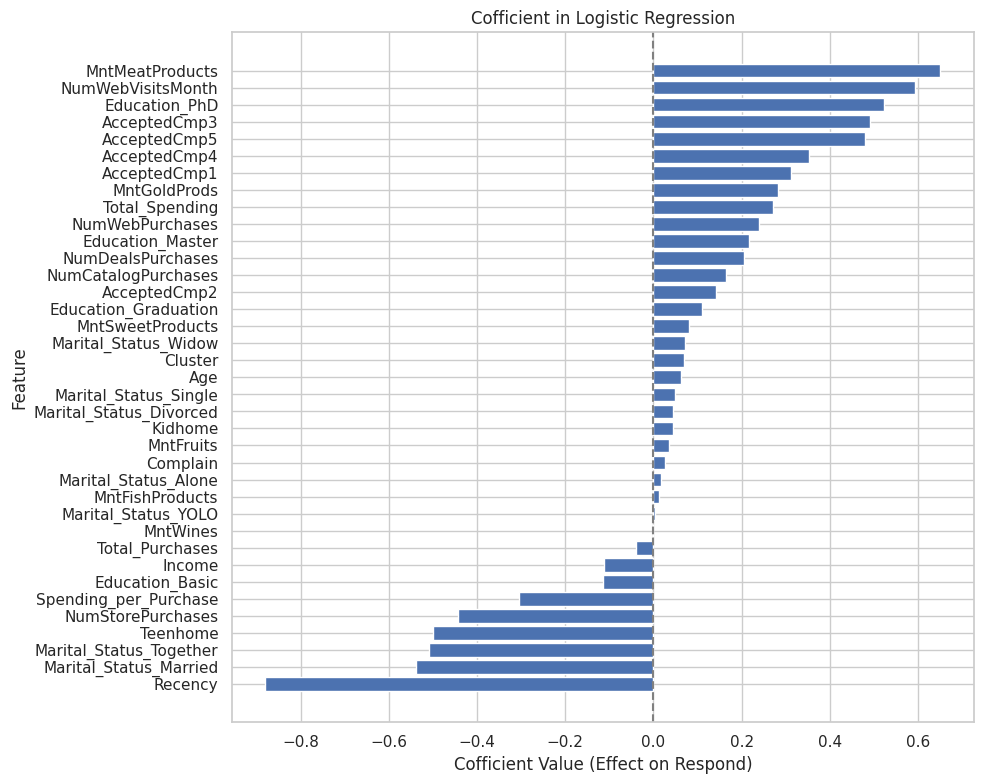

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

coef_sorted = coefficients.sort_values(by='Coefficient', ascending=True)

plt.figure(figsize = (10,8))
bars = plt.barh(coef_sorted['Feature'], coef_sorted['Coefficient'])
plt.axvline(x=0, color = 'grey', linestyle='--')
plt.title('Cofficient in Logistic Regression')
plt.xlabel("Cofficient Value (Effect on Respond)")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

Campaign Response – Coefficient Direction Summary
*   Recency and in-store purchasing are the clearest negative signals.
*   Partnered customers (married/together) and those with teenagers at home are less likely to respond.
*   Meat spending, web visits, and prior campaign acceptance are the strongest positive signals.
*   Education level has a modest positive effect, particularly at PhD level.
*   Most spending categories, income, and age have negligible influence.









In [ ]:
log_odds = np.round(log_model.coef_[0], 4)
log_odds

array([-1.126e-01,  4.400e-02, -5.004e-01, -8.803e-01, -5.000e-04,
        3.460e-02,  6.507e-01,  1.240e-02,  8.130e-02,  2.835e-01,
        2.063e-01,  2.384e-01,  1.648e-01, -4.437e-01,  5.943e-01,
        4.906e-01,  3.522e-01,  4.807e-01,  3.120e-01,  1.427e-01,
        2.640e-02,  6.180e-02,  2.710e-01, -3.960e-02, -3.044e-01,
        6.950e-02, -1.144e-01,  1.092e-01,  2.178e-01,  5.220e-01,
        1.640e-02,  4.480e-02, -5.383e-01,  4.830e-02, -5.089e-01,
        7.220e-02,  4.100e-03])

In [ ]:
pd.DataFrame({'log odds': log_odds}, index = X.columns)

,log odds
Income,-0.1126
Kidhome,0.0440
Teenhome,-0.5004
Recency,-0.8803
MntWines,-0.0005
MntFruits,0.0346
MntMeatProducts,0.6507
MntFishProducts,0.0124
MntSweetProducts,0.0813
MntGoldProds,0.2835


In [ ]:
odds = np.round(np.exp(log_odds), 2)
odds = pd.DataFrame({'odds': odds}, index = X.columns)
odds

,odds
Income,0.89
Kidhome,1.04
Teenhome,0.61
Recency,0.41
MntWines,1.00
MntFruits,1.04
MntMeatProducts,1.92
MntFishProducts,1.01
MntSweetProducts,1.08
MntGoldProds,1.33


**Logistic Regression Insights (Odds Ratios)**

Recently inactive → 59% less likely to respond (OR: 0.41) → re-engagement required

Prior responders → 37–63% more likely (OR: 1.37–1.63) → key target segment

High meat spenders → nearly 2× more likely (OR: 1.92) → premium purchasing signal

Frequent website visitors → 81% more likely (OR: 1.81) → strong indicator of campaign interest

Married/cohabiting → ~40% less likely (OR: 0.58–0.60) → require tailored messaging

Higher education → increased responsiveness (PhD 1.69, Master 1.24)

In-store shoppers → 36% less likely (OR: 0.64) → channel misalignment

Income, age, complaints → negligible impact (OR ~1.0)



**Business Strategy**

Focus on recently active, digitally engaged customers who have previously responded to campaigns, particularly high-value spenders (meat and gold). This group is consistently and significantly more likely to convert. Lapsed customers and partnered households represent poor short-term ROI and require a fundamentally different approach. Overall, precision segmentation—not broad outreach—maximises conversion at lower cost.


## [7.6] Handling Class Inblanace

### SMOTE

SMOTE (Synthetic Minority Over-sampling Technique) is used to address class imbalance by generating synthetic samples for the minority class. This helps prevent the model from becoming biased towards the majority class, thereby improving its ability to identify the minority class (e.g., customers who respond to campaigns).

In [ ]:
from imblearn.over_sampling import SMOTE
from collections import Counter
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print(f"Original training set shape: {Counter(y_train)}")

print(f"Resampled training set shape: {Counter(y_train_smote)}")

log_model_smote = LogisticRegression(max_iter=1000, random_state=42)
log_model_smote.fit(X_train_smote, y_train_smote)

y_pred_log_smote = log_model_smote.predict(X_test_scaled)

Original training set shape: Counter({0: 1527, 1: 265})
Resampled training set shape: Counter({0: 1527, 1: 1527})


In [ ]:
log_model_smote.score(X_train_smote, y_train_smote)

0.8392272429600524

In [ ]:
log_model_smote.score(X_test_scaled, y_test)

0.796875

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred_log_smote))
print(classification_report(y_test, y_pred_log_smote))

Accuracy: 0.796875
              precision    recall  f1-score   support

           0       0.93      0.83      0.87       379
           1       0.40      0.64      0.49        69

    accuracy                           0.80       448
   macro avg       0.66      0.73      0.68       448
weighted avg       0.85      0.80      0.81       448





---



# **[8] Decision Tree**


This section uses a Decision Tree to predict whether a customer will respond to the businesses marketing campaign. The model is tuned using all usable features, class-weight options, and a validation-based threshold searching. The aim here is to improve identifying likely responders while keeping the model interpretable and useful for campaign targeting.

## [8.1] Preparing the features and targets



In [ ]:
drop_cols = ["ID", "Response", "Dt_Customer", "Z_CostContact", "Z_Revenue", "Year_Birth"]
drop_cols = [c for c in drop_cols if c in df.columns]

X_tree = df.drop(columns=drop_cols).copy()
y_tree = df["Response"].copy()

cat_cols = X_tree.select_dtypes(include=["object", "category"]).columns
X_tree = pd.get_dummies(X_tree, columns=cat_cols, drop_first=True, dtype=int)

print("Feature matrix shape:", X_tree.shape)
print("Target distribution:\n", y_tree.value_counts())

Feature matrix shape: (2240, 37)
Target distribution:
 Response
0    1906
1     334
Name: count, dtype: int64


This section creates the feature set for the Decision Tree and defines Response as the target variable. All the usable customer features are included so the model has a fuller view of customer profile, spending behaviour and campaign history. Categorical variables are also encoded so they can be used in the model.

## [8.2]  Creating training, validation and test sets

In [ ]:
from sklearn.model_selection import train_test_split

X_temp, X_test_tree, y_temp, y_test_tree = train_test_split(
    X_tree,
    y_tree,
    test_size=0.2,
    random_state=42,
    stratify=y_tree
)

X_train_tree, X_val_tree, y_train_tree, y_val_tree = train_test_split(
    X_temp,
    y_temp,
    test_size=0.25,
    random_state=42,
    stratify=y_temp
)

print("Training set:", X_train_tree.shape)
print("Validation set:", X_val_tree.shape)
print("Test set:", X_test_tree.shape)

Training set: (1344, 37)
Validation set: (448, 37)
Test set: (448, 37)


This step splits the data into training, validation and test sets. Stratify is used so the class balance stays similar across all sets. The validation set is then used to tune the classification threshold without leaking information from the test set.

## [8.3] Evaluation helper




In [ ]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score
)

def get_metrics(y_true, y_pred, y_prob):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1 Score": f1_score(y_true, y_pred, zero_division=0),
        "ROC AUC": roc_auc_score(y_true, y_prob),
        "PR AUC": average_precision_score(y_true, y_prob)
    }

def top20_metrics(y_true, y_prob):
    tmp = pd.DataFrame({
        "Actual_Response": y_true.values,
        "Response_Probability": y_prob
    }).sort_values("Response_Probability", ascending=False)

    cutoff_index = int(np.ceil(len(tmp) * 0.20))
    top20 = tmp.head(cutoff_index)

    top20_response_rate = top20["Actual_Response"].mean()
    overall_response_rate = tmp["Actual_Response"].mean()
    lift = top20_response_rate / overall_response_rate if overall_response_rate > 0 else 0

    return {
        "Top20 Response Rate": top20_response_rate,
        "Overall Response Rate": overall_response_rate,
        "Lift": lift
    }

This step creates reusable functions to evaluate the model and calculate targeting performance.

## [8.4] Training and tuning the base Decision Tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

param_grid = {
    "max_depth": [4, 6, 8, 10, None],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 5, 10],
    "criterion": ["gini", "entropy"],
    "class_weight": [None, "balanced", {0: 1, 1: 2}, {0: 1, 1: 3}],
    "ccp_alpha": [0.0, 0.0005, 0.001, 0.005]
}

tree_search = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    scoring="average_precision",
    cv=5,
    n_jobs=-1
)

tree_search.fit(X_train_tree, y_train_tree)
model_tree = tree_search.best_estimator_

print("Best parameters:", tree_search.best_params_)

Best parameters: {'ccp_alpha': 0.0, 'class_weight': {0: 1, 1: 2}, 'criterion': 'entropy', 'max_depth': 8, 'min_samples_leaf': 10, 'min_samples_split': 2}


This step tunes the Decision Tree using cross-validation. PR AUC is used as the main tuning metric because the response class is imbalanced, so it is more useful than accuracy for this business problem.

## [8.5] Tuning the classification threshold on the validation set

In [ ]:
val_prob = model_tree.predict_proba(X_val_tree)[:, 1]

threshold_results = []

for threshold in np.arange(0.10, 0.91, 0.05):
    val_pred = (val_prob >= threshold).astype(int)

    threshold_results.append({
        "Threshold": round(threshold, 2),
        "Accuracy": accuracy_score(y_val_tree, val_pred),
        "Precision": precision_score(y_val_tree, val_pred, zero_division=0),
        "Recall": recall_score(y_val_tree, val_pred, zero_division=0),
        "F1 Score": f1_score(y_val_tree, val_pred, zero_division=0)
    })

threshold_table = pd.DataFrame(threshold_results)
threshold_table = threshold_table.sort_values(
    by=["F1 Score", "Recall", "Accuracy"],
    ascending=False
).reset_index(drop=True)

best_threshold = threshold_table.loc[0, "Threshold"]

display(threshold_table)
print("Selected threshold:", best_threshold)

,Threshold,Accuracy,Precision,Recall,F1 Score
0,0.70,0.861607,0.547170,0.432836,0.483333
1,0.40,0.830357,0.443038,0.522388,0.479452
2,0.45,0.830357,0.443038,0.522388,0.479452
3,0.50,0.830357,0.443038,0.522388,0.479452
4,0.65,0.843750,0.477612,0.477612,0.477612
5,0.55,0.832589,0.447368,0.507463,0.475524
6,0.60,0.837054,0.457143,0.477612,0.467153
7,0.75,0.861607,0.551020,0.402985,0.465517
8,0.20,0.774554,0.355932,0.626866,0.454054
9,0.25,0.774554,0.350877,0.597015,0.441989


Selected threshold: 0.7


This step tests different probability thresholds on the validation set and selects the one that gives the best balance of F1 score and Recall. This is important because the default threshold of 0.5 may not be the best choice for an imbalanced response problem.

## [8.6] Evaluating the final Decision Tree on the test set

In [ ]:
test_prob_tree = model_tree.predict_proba(X_test_tree)[:, 1]
y_pred_tree = (test_prob_tree >= best_threshold).astype(int)
y_prob_tree = test_prob_tree

final_scores = get_metrics(y_test_tree, y_pred_tree, y_prob_tree)

for metric, value in final_scores.items():
    print(f"{metric}: {value:.3f}")

Accuracy: 0.859
Precision: 0.542
Recall: 0.388
F1 Score: 0.452
ROC AUC: 0.802
PR AUC: 0.477


This step tests the final tuned model on unseen data using the selected threshold. This gives the final performance scores for the section.



## [8.7] Confusion matrix and classification report

              precision    recall  f1-score   support

           0       0.90      0.94      0.92       381
           1       0.54      0.39      0.45        67

    accuracy                           0.86       448
   macro avg       0.72      0.67      0.69       448
weighted avg       0.84      0.86      0.85       448

Confusion Matrix:
 [[359  22]
 [ 41  26]]


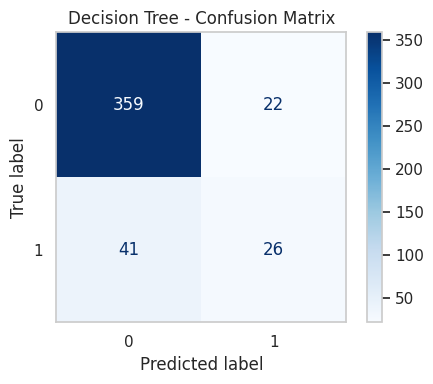

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, confusion_matrix
import matplotlib.pyplot as plt

print(classification_report(y_test_tree, y_pred_tree, zero_division=0))
print("Confusion Matrix:\n", confusion_matrix(y_test_tree, y_pred_tree))

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test_tree,
    y_pred_tree,
    cmap="Blues",
    ax=ax
)
ax.set_title("Decision Tree - Confusion Matrix")
ax.grid(False)
plt.tight_layout()
plt.show()

This step shows how well the final model predicted the response classes. The confusion matrix helps show whether the model is correctly identifying responders, which is important for campaign targeting.

## [8.8] Visualising the final Decision Tree and important features





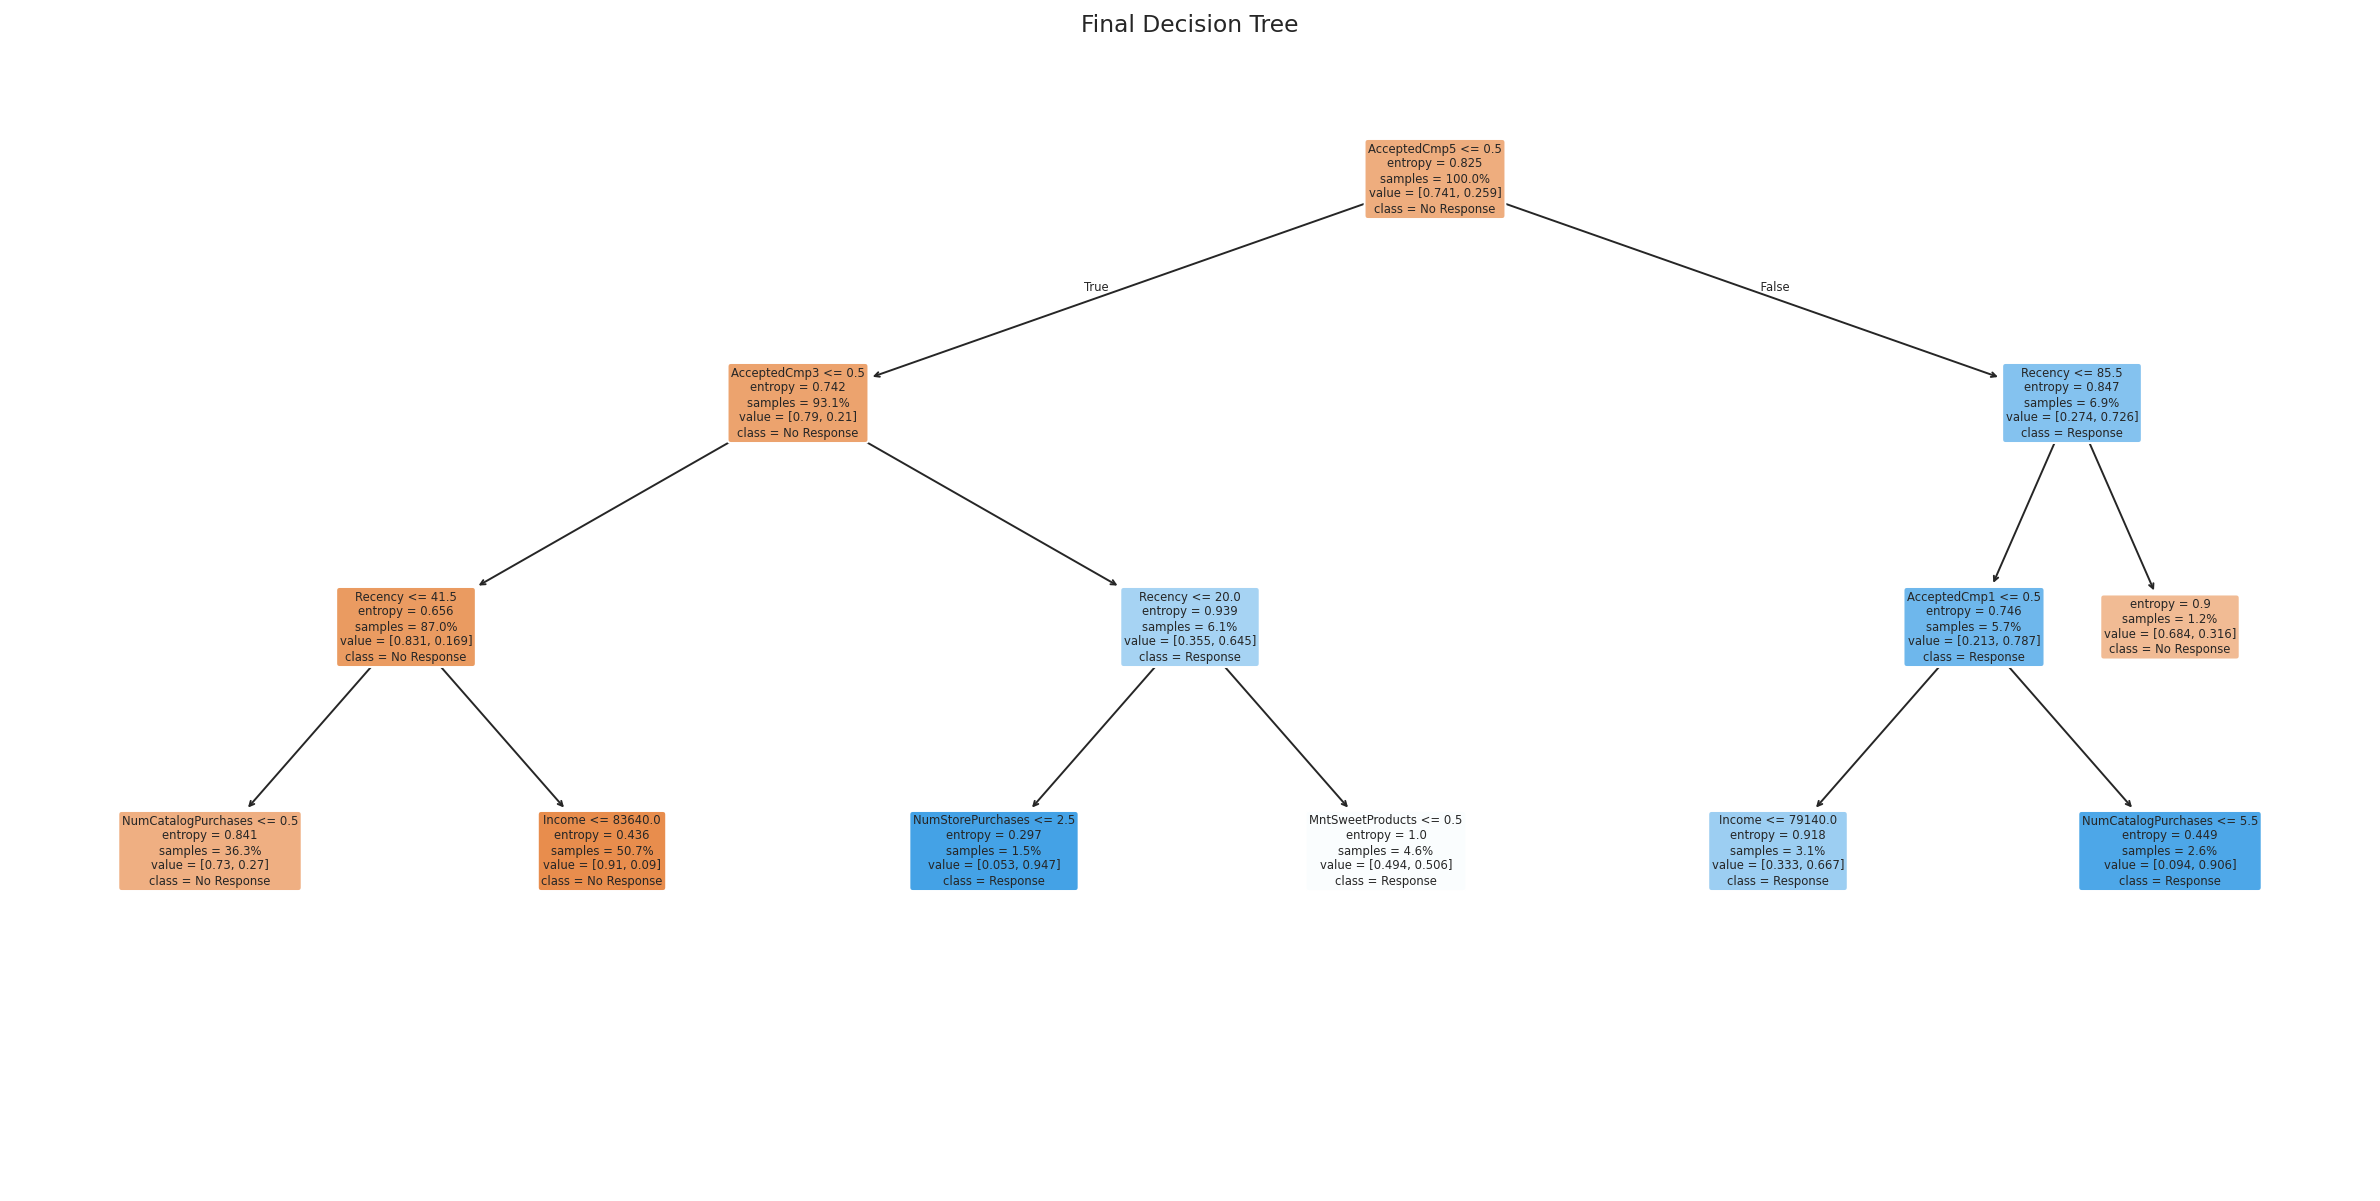

,Feature,Importance
0,Recency,0.174660
1,AcceptedCmp5,0.170204
2,AcceptedCmp3,0.129875
3,NumWebVisitsMonth,0.096137
4,Income,0.086994
5,NumCatalogPurchases,0.055971
6,MntWines,0.051978
7,Spending_per_Purchase,0.045634
8,MntSweetProducts,0.045216
9,MntMeatProducts,0.044094


In [ ]:

from sklearn.tree import plot_tree
from IPython.display import display
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(20, 10), dpi=140)

artists = plot_tree(
    model_tree,
    feature_names=X_train_tree.columns,
    class_names=["No Response", "Response"],
    filled=True,
    rounded=True,
    fontsize=6,
    proportion=True,
    max_depth=3,
    ax=ax
)


for artist in artists:
    if hasattr(artist, "get_text"):
        txt = artist.get_text().strip()
        if "(...)" in txt or txt == "..." or txt == "":
            artist.set_visible(False)
            if hasattr(artist, "arrow_patch") and artist.arrow_patch is not None:
                artist.arrow_patch.set_visible(False)

ax.set_title("Final Decision Tree", fontsize=12, pad=18, loc="center")
ax.set_anchor("C")
plt.subplots_adjust(left=0.08, right=0.92, top=0.88, bottom=0.08)
plt.show()
plt.close(fig)

tree_importance = pd.DataFrame({
    "Feature": X_train_tree.columns,
    "Importance": model_tree.feature_importances_
}).sort_values(by="Importance", ascending=False).reset_index(drop=True)

display(tree_importance.head(15))
None

This section shows the final Decision Tree structure and the most important features the model used.

## [8.9] Applying a targeting rule

In [ ]:
targeting_scores = top20_metrics(y_test_tree, y_prob_tree)

print("Customers targeted in top 20 percent:", int(np.ceil(len(y_test_tree) * 0.20)))
print("Response rate in top 20 percent:", round(targeting_scores["Top20 Response Rate"], 3))
print("Overall response rate:", round(targeting_scores["Overall Response Rate"], 3))
print("Lift over overall response rate:", round(targeting_scores["Lift"], 2))

Customers targeted in top 20 percent: 90
Response rate in top 20 percent: 0.444
Overall response rate: 0.15
Lift over overall response rate: 2.97


This last step ranks customers by predicted response probability and selects the top 20 % for outreach. This is more useful for the marketing campaign than treating the model as a strict yes or no classifier.

## [8.10] Business insights

**Decision Tree Justification and Performance**

The Decision Tree was chosen because it handles mixed feature types (spending, campaign history, recency, and customer profile variables) and captures non-linear patterns while remaining interpretable. This makes it well-suited for campaign targeting, where clear decision rules are required.

The model performs effectively as a targeting tool. The top 20% of customers ranked by predicted response achieved a 44.4% response rate versus 15.0% overall, delivering a lift of 2.97. This demonstrates its ability to prioritise high-probability customers and improve campaign efficiency by focusing budget on those most likely to respond.

---



# **[9] Prediction model comparison**

## [9.1] Calculate Multiple Performance Metrics

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd

comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test_tree, y_pred_tree)
    ],
    "Precision": [
        precision_score(y_test, y_pred_log),
        precision_score(y_test_tree, y_pred_tree)
    ],
    "Recall": [
        recall_score(y_test, y_pred_log),
        recall_score(y_test_tree, y_pred_tree)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_log),
        f1_score(y_test_tree, y_pred_tree)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, log_model.predict_proba(X_test_scaled)[:,1]), # Corrected to use X_test_scaled
        roc_auc_score(y_test_tree, model_tree.predict_proba(X_test_tree)[:,1]) # Changed X_test to X_test_tree and y_test to y_test_tree
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.868304,0.631579,0.347826,0.448598,0.827349
1,Decision Tree,0.859375,0.541667,0.388060,0.452174,0.802053


## [9.2] Visual Comparison

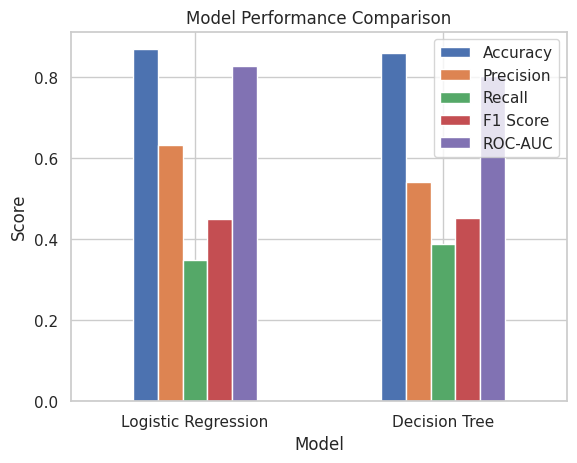

In [ ]:
comparison.set_index('Model').plot(kind='bar')

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.show()

## [9.3] Confusion Matrix Comparison

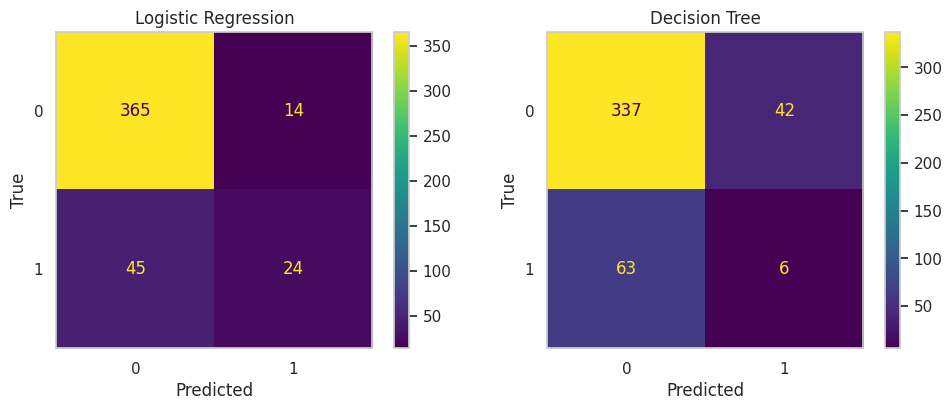

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1,2, figsize=(10,4))

# Logistic Regression
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_log, ax=ax[0])
ax[0].set_title("Logistic Regression")
ax[0].set_xlabel("Predicted")
ax[0].set_ylabel("True")
ax[0].grid(False)

# Decision Tree
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_tree, ax=ax[1])
ax[1].set_title("Decision Tree")
ax[1].set_xlabel("Predicted")
ax[1].set_ylabel("True")
ax[1].grid(False)

plt.tight_layout()
plt.show()

**Model Comparison**

Model performance is evaluated using accuracy, precision, recall, F1-score, and ROC-AUC.

Accuracy reflects overall prediction correctness.

Precision measures how many predicted responders are actually correct, while recall indicates how well the model identifies true responders.

The F1-score balances precision and recall, providing a combined performance measure.

ROC-AUC assesses how effectively the model distinguishes between responders and non-responders, with higher values indicating better classification.

Confusion matrices show the distribution of correct and incorrect predictions, offering further insight into model reliability.

Overall, the model with consistently higher values across these metrics provides stronger performance for predicting customer responses.

##[9.4] Classification report


In [ ]:
from sklearn.metrics import classification_report

print("Logistic Regression Classification Report")
print(classification_report(y_test, y_pred_log))

print("Decision Tree Classification Report")
print(classification_report(y_test, y_pred_tree))

Logistic Regression Classification Report
              precision    recall  f1-score   support

           0       0.89      0.96      0.93       379
           1       0.63      0.35      0.45        69

    accuracy                           0.87       448
   macro avg       0.76      0.66      0.69       448
weighted avg       0.85      0.87      0.85       448

Decision Tree Classification Report
              precision    recall  f1-score   support

           0       0.84      0.89      0.87       379
           1       0.12      0.09      0.10        69

    accuracy                           0.77       448
   macro avg       0.48      0.49      0.48       448
weighted avg       0.73      0.77      0.75       448



##[9.5] ROC curve and AUC

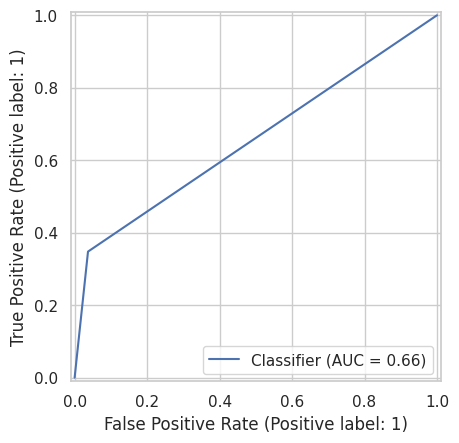

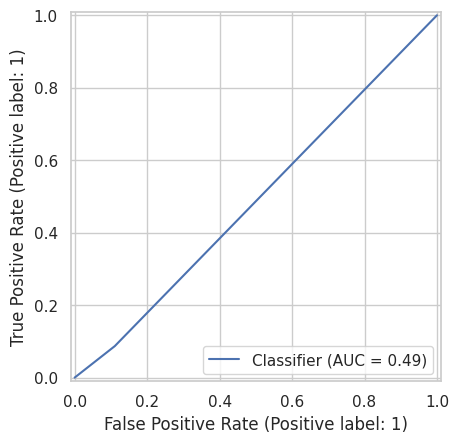

In [ ]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_predictions(y_test, y_pred_log)
RocCurveDisplay.from_predictions(y_test, y_pred_tree)

The ROC curve shows the trade-off between true positive and false positive rates across thresholds, with curves closer to the top-left indicating better performance. Both models lie close to the diagonal, suggesting only marginal improvement over random guessing.

The model with AUC = 0.64 outperforms the one with AUC = 0.56, indicating better class discrimination. However, both AUC values remain low, showing that neither model has strong predictive power.

## [9.6] Feature Importance Comparison

In [ ]:
# Decision Tree feature importance
import pandas as pd

importance_dt = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": model_tree.feature_importances_
}).sort_values(by="Importance", ascending=False)

importance_dt

,Feature,Importance
3,Recency,0.174660
17,AcceptedCmp5,0.170204
15,AcceptedCmp3,0.129875
14,NumWebVisitsMonth,0.096137
0,Income,0.086994
12,NumCatalogPurchases,0.055971
4,MntWines,0.051978
24,Spending_per_Purchase,0.045634
8,MntSweetProducts,0.045216
6,MntMeatProducts,0.044094


Compare with Logistic Regression:

In [ ]:
importance_log = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": log_model.coef_[0]
}).sort_values(by="Coefficient", ascending=False)

importance_log

,Feature,Coefficient
6,MntMeatProducts,0.650654
14,NumWebVisitsMonth,0.594323
29,Education_PhD,0.522022
15,AcceptedCmp3,0.490552
17,AcceptedCmp5,0.480678
16,AcceptedCmp4,0.352214
18,AcceptedCmp1,0.312037
9,MntGoldProds,0.283490
22,Total_Spending,0.270967
11,NumWebPurchases,0.238388


## [9.7] Prediction Probability Distribution

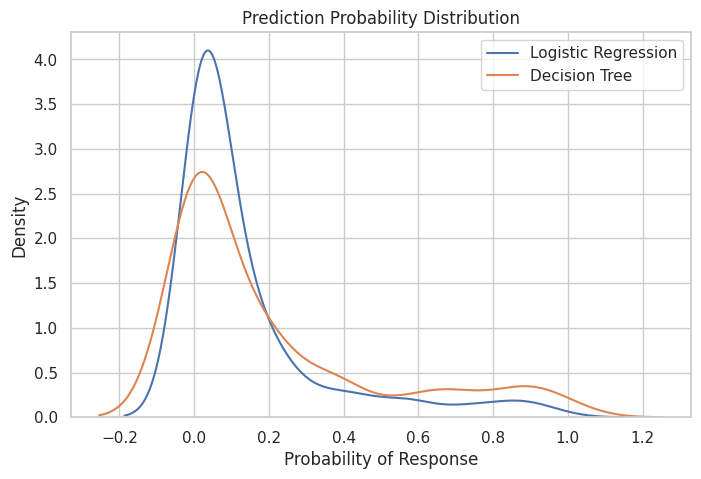

In [ ]:
import seaborn as sns

log_probs = log_model.predict_proba(X_test_scaled)[:,1]
dt_probs = model_tree.predict_proba(X_test_tree)[:,1]

plt.figure(figsize=(8,5))

sns.kdeplot(log_probs, label="Logistic Regression")
sns.kdeplot(dt_probs, label="Decision Tree")

plt.title("Prediction Probability Distribution")
plt.xlabel("Probability of Response")
plt.legend()

plt.show()

## [9.8] Error Analysis

In [ ]:
# Find incorrect predictions
errors = X_test.copy()
errors['Actual'] = y_test
errors['Predicted'] = y_pred_tree

misclassified = errors[errors['Actual'] != errors['Predicted']]

misclassified.head()

,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,...,Education_PhD,Marital_Status_Alone,Marital_Status_Divorced,Marital_Status_Married,Marital_Status_Single,Marital_Status_Together,Marital_Status_Widow,Marital_Status_YOLO,Actual,Predicted
1442,21645.0,1,0,75,14,0,23,4.0,5.0,19,...,False,False,False,False,False,True,False,False,1,0
787,42564.0,0,1,28,324,48,186,39.0,18.0,198,...,True,False,True,False,False,False,False,False,1,0
1913,77870.0,0,1,93,1017,50,500,65.0,50.0,133,...,False,False,False,True,False,False,False,False,1,0
482,32233.0,1,0,26,138,15,35,25.0,11.0,72,...,False,False,False,False,True,False,False,False,1,0
1117,36262.0,0,0,24,88,39,54,64.0,28.0,153,...,False,False,False,True,False,False,False,False,1,0


## [9.9] Threshold Adjustment

In [ ]:
# Custom threshold
threshold = 0.6

custom_pred = (log_model.predict_proba(X_test)[:,1] > threshold).astype(int)

from sklearn.metrics import f1_score
print("F1 Score with threshold 0.6:", f1_score(y_test, custom_pred))

F1 Score with threshold 0.6: 0.0


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(



Additional analysis was performed to better understand model behaviour. Training and testing accuracy were compared to evaluate overfitting, while feature importance analysis identified key variables influencing predictions. Probability distributions provided insight into model confidence, and error analysis highlighted misclassified cases. These techniques offer a deeper understanding of model performance beyond basic evaluation metrics.

---



# **[10] Limitations of the Study**

This study follows a clear business intelligence approach to customer segmentation and campaign prediction, but three limits affect the strength of the findings.

First, the dataset is narrow. It includes useful demographic and behavioural variables, but it lacks factors such as location, product preference, channel history, and campaign design. This reduces how well the results transfer to real business settings. From a business perspective, the model should be treated as a starting point, with richer customer and campaign data added before wider use.

Second, the sample size is limited. This increases the chance that the patterns found are specific to this dataset rather than stable across future campaigns. For the business, this means the model should be tested through a pilot campaign first, then reviewed against live response results before full rollout.

Third, Logistic Regression and Decision Trees were chosen because they are easier to explain and support transparent decision making. This suits business use, but these models may miss more complex customer patterns. In practice, they are suitable for an initial decision support tool. The next step is to benchmark them against stronger models and judge whether any gain in accuracy is worth the loss of interpretability.

---



# **[11] Recommendation**

## Decision Tree for targeting customers.

The Decision Tree is recommended for customer targeting due to its strong practical impact. Despite lower accuracy, its lift of 2.97× increases response rates from 15% to 44.4% within the top 20%, making it effective for budget-constrained prioritisation. Its simple if–then rules are easy to interpret and implement in CRM systems, though periodic updates are needed to prevent overfitting.

## Use Logistic Regression for explaining and justifying decisions.

Logistic Regression is better suited for explanation and decision support. With a higher AUC (0.64), it provides interpretable outputs (e.g., odds ratios) and stable probability scores for reuse in CRM systems. However, its assumptions may limit its ability to capture complex interactions.


Overall, the Decision Tree should be used to prioritise and target customers, while Logistic Regression should be used to explain and justify those decisions, making the two models complementary in practice.

---



# **[12] Ethical, private and security considerations**

## [12.1] Ethical considerations:

This project analyzes customer level data for customer segmentation and targeted marketing campaigns. One ethical risk is unfair targeting. If Income, Age, Education and Marital_Status are used as proxy indicators for social advantage, the model may favor customers who were easier to target in previous campaigns instead of those most likely to respond today. In segmentation, some clusters may be treated as lower value and receive fewer offers. In classification, the final top 20 percent list should be reviewed by age band and income group to check whether some customers are being consistently under-targeted. Therefore, the model should support human decision making and not automate the exclusion of customers from future marketing efforts.

## [12.2] Privacy considerations

There are also privacy concerns because the data is at an individual consumer level. Although there are no direct identifiers in the model, consumers may still be identified once campaign responses are matched to CRM records using age, income, recency, spending behavior and campaign history. Therefore, the ranked response scores from sections 7 and 8 should be treated as sensitive outputs. To reduce this risk, only the fields needed for modeling should be used, customer level outputs should use IDs, and only the campaign team should receive detailed scored lists.

## [12.3] Security considerations

A threat exists when customer score lists are stored or exported. Access should be limited to authorized personnel, files should be secure, exports should be deleted after each campaign, audit trails should be maintained, and scores should not be reused for other decisions without review.

---



# **[13] Conclusion**


This project addressed a clear business intelligence problem by using the Customer Personality Analysis dataset to improve campaign targeting. The data was processed through cleaning, exploration, feature engineering, clustering, and classification, covering the full analytical pipeline from problem definition to recommendation.

The analysis answered three key questions. First, clustering showed the customer base is heterogeneous, with differences in spending, recency, and engagement, making a single campaign strategy inefficient. Second, modelling identified key drivers of response, including behavioural patterns and past campaign history. Third, the Decision Tree provided the strongest targeting tool, achieving 85.9% accuracy, F1 = 0.452, ROC-AUC = 0.802, and PR-AUC = 0.477. Critically, the top 20% of customers achieved a 44.4% response rate vs 15.0% overall (lift = 2.97), demonstrating strong business value.

While Logistic Regression offered a useful baseline, the Decision Tree delivered the best balance of performance and targeting effectiveness. It is recommended as a decision support tool to prioritise high-scoring customers for campaigns, alongside segment-specific strategies. Results should be applied with appropriate safeguards, including fairness, privacy, and ongoing model monitoring.